# AMLGuard: Anti-Money Laundering Detection under Extreme Class Imbalance

**Author:** Caio Bernardinelli  
**Date:** June 2026  
**Course:** Técnico em Inteligência Artificial — IFNMG  
**Objective:** Build a machine-learning pipeline to detect money-laundering transactions in the IBM AML dataset under extreme class imbalance.

---

## 1. Dataset Presentation

### Business context

The European Union's **Anti-Money Laundering Authority (AMLA)** is headquartered in Frankfurt and began most of its activities in 2025. On **1 January 2026**, AMLA assumed the EU-level AML/CFT mandates previously held by the European Banking Authority (EBA). AMLA plans to select up to 40 high-risk financial-sector entities in 2027 for direct supervision beginning in 2028.

Official references:
- [EBA and AMLA complete the handover of AML/CFT mandates](https://www.amla.europa.eu/eba-and-amla-complete-handover-amlcft-mandates_en)
- [AMLA risk-assessment work supporting the selection of directly supervised entities](https://www.amla.europa.eu/amla-launch-data-collection-exercise-test-risk-assessment-models-financial-sector_en)

The technical challenge addressed by this project is **extreme class imbalance**. Illicit transactions represent approximately 0.1% of this dataset. A classifier that labels every transaction as legitimate would therefore achieve about 99.9% accuracy while detecting no laundering. The project consequently prioritises precision–recall metrics, threshold selection and operational alert quality rather than accuracy alone.

### Dataset

**Source:** IBM Transactions for Anti-Money Laundering (AML)  
**Link:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml  
**License:** Community Data License Agreement — Sharing — Version 1.0  
**Version used:** HI-Small (high illicit ratio; smallest version for rapid iteration)

### Variable description

| Column | Type | Description |
|---|---|---|
| Timestamp | object | Date and time of the transaction |
| From Bank | int64 | Identifier of the sending bank |
| Account | object | Account number of the sender |
| To Bank | int64 | Identifier of the receiving bank |
| Account.1 | object | Account number of the receiver |
| Amount Received | float64 | Amount received by the destination account |
| Receiving Currency | object | Currency of the received amount |
| Amount Paid | float64 | Amount paid by the source account |
| Payment Currency | object | Currency of the paid amount |
| Payment Format | object | Payment method, such as Cheque, Wire or Reinvestment |
| Is Laundering | int64 | **Target variable** — 1 = illicit, 0 = legitimate |

> **Dataset limitation:** the data are synthetic and cover only 18 days. Strong patterns may reflect simulator rules rather than generalisable real-world laundering behaviour. Every high-lift feature is therefore interpreted critically.


In [ ]:
# ============================================================================
# SETUP & IMPORTS
# ============================================================================

from pathlib import Path
from time import perf_counter

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Preparation and baseline modelling
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Global random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Core libraries imported successfully")
print(f"✓ Random state fixed: {RANDOM_STATE}")

✓ Core libraries imported successfully
✓ Random state fixed: 42


## 2. Data Loading

The `HI-Small_Trans.csv` file is ~476 MB and is hosted on Google Drive rather than committed to the repository (the `.gitignore` excludes `*.csv`). It is downloaded at runtime with `gdown`, so the notebook is fully reproducible from a fresh clone: anyone running it fetches the data automatically, without needing the file in version control.

After loading, we run a first inspection — shape, column names, data types, memory footprint, and the distribution of the target variable — to confirm the data arrived intact and to quantify the class imbalance before any analysis.

In [ ]:
# ============================================================================
# 2. DATA LOADING
# ============================================================================

print("=" * 80)
print("2. DATA LOADING")
print("=" * 80)

DATA_PATH = Path("HI-Small_Trans.csv")
FILE_ID = "1359N_tsRuUtCFMWCV6BtHjDdF280rb8e"

if not DATA_PATH.exists():
    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        str(DATA_PATH),
        quiet=False,
    )
else:
    print(f"✓ Reusing local file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

TARGET = "Is Laundering"
BASE_RATE = df[TARGET].mean()

print(f"\n✓ Dataset loaded successfully")
print(f"\n{'─' * 40}")
print(f"Shape:        {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'─' * 40}")

print("\n--- First 10 rows ---")
print(df.head(10))

print("\n--- Data types ---")
print(df.dtypes)

print(f"\n--- Target variable ({TARGET}) ---")
print(df[TARGET].value_counts())
print(f"\nIllicit transactions: {BASE_RATE:.4%}")


2. DATA LOADING
✓ Reusing local file: HI-Small_Trans.csv

✓ Dataset loaded successfully

────────────────────────────────────────
Shape:        5,078,345 rows × 11 columns
Memory usage: 1890.96 MB
────────────────────────────────────────

--- First 10 rows ---
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   
5  2022/09/01 00:03          1  8000F5AD0        1  8000F5AD0   
6  2022/09/01 00:08          1  8000EBAC0        1  8000EBAC0   
7  2022/09/01 00:16          1  8000EC1E0        1  8000EC1E0   
8  2022/09/01 00:26         12  8000EC280     2439  8017BF800   
9  2022/09/01 00:21          1  8000EDEC0   211050  80AEF5310   

   Amount Received Rece

**Key finding — the imbalance is even more extreme than expected.**

The dataset holds **5,078,345 transactions** across 11 columns. Only **5,177** are labelled as laundering — **0.1019%** of the total, roughly one illicit transaction in every 980. This is well below the "under 1%" rule of thumb and sets the methodological constraints for the entire pipeline: stratified train/test split, precision–recall-oriented metrics (PR-AUC) instead of accuracy, and explicit handling of imbalance (class weighting / resampling) during modelling.

## 3. Descriptive Analysis

Before modelling, we characterise the data and test three hypotheses about *where* laundering concentrates. Given the extreme imbalance (base rate 0.1019%), the guiding principle throughout this section is to compare **illicit rate**, not raw counts: a frequent category will naturally contain more illicit cases in absolute terms simply because it contains more of everything. What signals risk is a group whose *proportion* of laundering sits well above the global base rate.

Each hypothesis below follows the same pattern — derive a flag, group by it, and read the mean of the target (which, for a 0/1 column, is the illicit rate of the group).

In [ ]:
# ============================================================================
# 3. DESCRIPTIVE ANALYSIS
# ============================================================================

print("="*80)
print("3. DESCRIPTIVE ANALYSIS")
print("="*80)

# --- 3.1 Numeric overview ---
print("\n--- Amount Paid / Received: statistics ---")
print(df[['Amount Paid', 'Amount Received']].describe())

# --- 3.2 Categorical cardinality ---
print("\n--- Cardinality of categorical variables ---")
for col in ['Receiving Currency', 'Payment Currency', 'Payment Format', 'From Bank', 'To Bank']:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n--- Payment Format distribution ---")
print(df['Payment Format'].value_counts())

print("\n--- Top 10 currencies (Payment) ---")
print(df['Payment Currency'].value_counts().head(10))

3. DESCRIPTIVE ANALYSIS

--- Amount Paid / Received: statistics ---
        Amount Paid  Amount Received
count  5.078345e+06     5.078345e+06
mean   4.509273e+06     5.988726e+06
std    8.697728e+08     1.037183e+09
min    1.000000e-06     1.000000e-06
25%    1.844800e+02     1.833700e+02
50%    1.414540e+03     1.411010e+03
75%    1.229784e+04     1.234627e+04
max    1.046302e+12     1.046302e+12

--- Cardinality of categorical variables ---
Receiving Currency: 15 unique values
Payment Currency: 15 unique values
Payment Format: 7 unique values
From Bank: 30470 unique values
To Bank: 15811 unique values

--- Payment Format distribution ---
Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64

--- Top 10 currencies (Payment) ---
Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            2137

### H1 — Cross-currency transactions

**Hypothesis:** moving money across currencies (paid ≠ received currency) could help shift wealth across borders and hinder tracing.

**Reading:** the hypothesis **cannot be tested on this dataset**. Cross-currency transactions are only 1.42% of all records (72,170 of 5.08M), and — decisively — **none** of them are labelled as laundering (0 illicit in 72,170). All 5,177 illicit cases are same-currency. This is a property of the synthetic generator, which never tags a cross-currency transaction as illicit, rather than an economic pattern. The flag therefore acts as a perfect *negative* predictor (cross-currency ⇒ certainly legitimate), which is a simulator artifact and not a generalizable signal. It will be **excluded** from modelling to avoid leakage, and noted as a dataset limitation in the conclusion.

In [ ]:
df["is_cross_currency"] = (
    df["Payment Currency"] != df["Receiving Currency"]
).astype("int8")

print("--- Cross-currency share of all transactions (%) ---")
print(df["is_cross_currency"].value_counts(normalize=True) * 100)

print("\n--- Illicit rate by cross-currency flag ---")
df.groupby("is_cross_currency")["Is Laundering"].agg(["mean", "count", "sum"])

--- Cross-currency share of all transactions (%) ---
is_cross_currency
0    98.578868
1     1.421132
Name: proportion, dtype: float64

--- Illicit rate by cross-currency flag ---


,mean,count,sum
is_cross_currency,,,
0,0.001034,5006175,5177
1,0.000000,72170,0


### H2 — Payment format and laundering

**Hypothesis:** some payment methods offer easier laundering channels, so their illicit rate should exceed the global base rate (0.1019%).

Two complementary readings are distinguished throughout: **Reading A** — the illicit rate *within* a group (its actual risk level, comparable against the base rate); **Reading B** — the group's share of *all* illicit cases (its concentration, which is inflated by sheer volume). Only Reading A supports a risk conclusion.

**Reading:** only **ACH** stands out. Its illicit rate is **0.7462%** — about **7.3× the global base rate** — and it concentrates **86.6%** of all illicit cases. Crucially, the intuition that low-traceability channels (Bitcoin, Cash) would lead does **not** hold here: Bitcoin (0.0383%) and Cash (0.0220%) sit *below* the base rate, so a transaction in those formats is, if anything, *less* likely to be illicit than average. Their apparent prominence among illicit cases was a volume artifact (Reading B), not elevated risk (Reading A). Two formats — Reinvestment and Wire — contain **zero** illicit cases across hundreds of thousands of transactions, mirroring the generator-rule pattern seen in H1. ACH is therefore the only payment-format signal worth keeping as a feature, but its 7× concentration likely reflects how the synthetic generator routes laundering events rather than a real-world property of ACH, and is flagged as a dataset bias in the conclusion.

In [ ]:
fmt = df.groupby('Payment Format')['Is Laundering'].agg(['mean', 'count', 'sum'])

fmt = fmt.rename(columns={
    'mean':  'illicit_rate',     # illicit rate WITHIN the format (Reading A)
    'count': 'n_transactions',   # total volume of the format
    'sum':   'n_illicit'         # absolute illicit count
})

# Reading A — illicit rate within the format, as %
fmt['illicit_rate_%'] = (fmt['illicit_rate'] * 100).round(4)

# Legitimate rate within the format (complement of the illicit rate)
fmt['legit_rate_%'] = (100 - fmt['illicit_rate_%']).round(4)

# Reading B — how much each format represents of all illicit cases
fmt['%_of_all_illicit'] = (fmt['n_illicit'] / fmt['n_illicit'].sum() * 100).round(2)

# Context — how much each format represents of total volume
fmt['%_of_all_tx'] = (fmt['n_transactions'] / fmt['n_transactions'].sum() * 100).round(2)

fmt = fmt[['n_transactions', '%_of_all_tx', 'n_illicit',
           '%_of_all_illicit', 'illicit_rate_%', 'legit_rate_%']]
fmt = fmt.sort_values('illicit_rate_%', ascending=False)

print(f"Global base rate: {df['Is Laundering'].mean()*100:.4f}%\n")
print(fmt)

Global base rate: 0.1019%

                n_transactions  %_of_all_tx  n_illicit  %_of_all_illicit  \
Payment Format                                                             
ACH                     600797        11.83       4483             86.59   
Bitcoin                 146091         2.88         56              1.08   
Cash                    490891         9.67        108              2.09   
Cheque                 1864331        36.71        324              6.26   
Credit Card            1323324        26.06        206              3.98   
Reinvestment            481056         9.47          0              0.00   
Wire                    171855         3.38          0              0.00   

                illicit_rate_%  legit_rate_%  
Payment Format                                
ACH                     0.7462       99.2538  
Bitcoin                 0.0383       99.9617  
Cash                    0.0220       99.9780  
Cheque                  0.0174       99.9826  
Credit

### H3 — Same-bank vs. cross-bank transactions

**Hypothesis:** transactions between different banks or accounts could facilitate laundering by moving funds away from their point of origin.

**Reading:** the direction holds descriptively, but the effect is **weak**. Cross-bank transactions show an illicit rate of **0.1157%** versus **0.0149%** for same-bank transactions. However, the cross-bank rate is only **1.14× the global base rate** of 0.1019%, far below the lift observed for ACH. The fact that 98% of illicit cases are cross-bank is not sufficient evidence by itself because 86% of all transactions are already cross-bank; the relevant comparison is the rate within each group.

At this stage, `same_bank` is retained only as a **candidate**. Section 5 later introduces the more granular `same_account` flag and shows high redundancy between them, so `same_bank` is removed from the final feature set rather than presenting both versions of the same structural signal to the model.


In [ ]:
df["same_bank"] = (df["From Bank"] == df["To Bank"]).astype("int8")

same_bank = df.groupby("same_bank")["Is Laundering"].agg(["mean", "count", "sum"])
same_bank = same_bank.rename(
    columns={"mean": "illicit_rate", "count": "n_transactions", "sum": "n_illicit"}
)
same_bank["illicit_rate_%"] = (same_bank["illicit_rate"] * 100).round(4)
same_bank["%_of_all_tx"] = (
    same_bank["n_transactions"] / same_bank["n_transactions"].sum() * 100
).round(2)
same_bank["%_of_all_illicit"] = (
    same_bank["n_illicit"] / same_bank["n_illicit"].sum() * 100
).round(2)
same_bank = same_bank.rename(index={0: "Different banks", 1: "Same bank"})

print(f"Global base rate: {df['Is Laundering'].mean()*100:.4f}%\n")
print(
    same_bank[
        ["n_transactions", "%_of_all_tx", "n_illicit", "%_of_all_illicit", "illicit_rate_%"]
    ]
)

Global base rate: 0.1019%

                 n_transactions  %_of_all_tx  n_illicit  %_of_all_illicit  \
same_bank                                                                   
Different banks         4387013        86.39       5074             98.01   
Same bank                691332        13.61        103              1.99   

                 illicit_rate_%  
same_bank                        
Different banks          0.1157  
Same bank                0.0149  


**Section summary**

The three initial hypotheses produced one strong signal, one weak structural candidate and one clear simulator artifact. The methodological lesson across all analyses is to compare the illicit **rate within each group**, never raw counts: high-volume categories naturally accumulate more illicit cases even when their underlying risk is low.

- **H1 — Cross-currency:** not meaningfully testable in this dataset. The 72,170 cross-currency transactions contain zero illicit labels, creating an unrealistically perfect negative predictor. The feature is excluded as a generator artifact and leakage risk.
- **H2 — Payment format:** ACH is the strongest observed signal, with an illicit rate of 0.7462% (7.3× the base rate) and 86.6% of all illicit labels. Bitcoin and Cash remain below the base rate. Payment format is retained, while its unusually strong synthetic pattern is documented as a limitation.
- **H3 — Same bank vs. different banks:** the direction is consistent with the hypothesis but the lift is weak. `same_bank` remains a temporary candidate here and is later removed after the more granular `same_account` flag is created and their redundancy is measured.

**Implication for modelling:** accuracy is not an adequate primary metric at a 0.1019% base rate. Evaluation will use Average Precision / precision–recall analysis, recall at an operationally acceptable precision, and confusion-matrix counts. Zero-illicit categories and other unusually strong rules are treated as possible simulator behaviour rather than automatically accepted as real-world AML knowledge.


## 4. Data Cleaning

This dataset is synthetic and generated by IBM's multi-agent simulator, so it is expected to arrive with high integrity and without the noise typical of real-world financial data. Rather than assuming this, the checks below verify it explicitly: missing values, exact duplicates, data types, and timestamp parseability.

> **Note on ordering:** cleaning is presented after the descriptive analysis (Section 3) for narrative flow, but the checks below confirm the dataset was already complete and well-typed — so the Section 3 conclusions rest on untreated, intact data, with no risk of contamination from missing or malformed values.

In [ ]:
# ============================================================================
# 4. DATA CLEANING
# ============================================================================

print("="*80)
print("4. DATA CLEANING")
print("="*80)

# --- 4.1 Missing values ---
print("\n--- Missing values per column ---")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_table = pd.DataFrame({'n_missing': missing, 'pct_%': missing_pct})
print(missing_table[missing_table['n_missing'] > 0] if missing.sum() > 0 else "No missing values found.")

# --- 4.2 Duplicates (full-row) ---
print("\n--- Full-row duplicates ---")
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.4f}%)")

# --- 4.3 Data types check ---
print("\n--- Current dtypes ---")
print(df.dtypes)

# --- 4.4 Timestamp parsing check ---
print("\n--- Timestamp: parseable check ---")
parsed = pd.to_datetime(df['Timestamp'], errors='coerce')
print(f"Failed to parse: {parsed.isna().sum():,} of {len(df):,}")
print(f"Date range: {parsed.min()} → {parsed.max()}")

4. DATA CLEANING

--- Missing values per column ---
No missing values found.

--- Full-row duplicates ---
Exact duplicate rows: 9 (0.0002%)

--- Current dtypes ---
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
is_cross_currency        int8
same_bank                int8
dtype: object

--- Timestamp: parseable check ---
Failed to parse: 0 of 5,078,345
Date range: 2022-09-01 00:00:00 → 2022-09-18 16:18:00


**Cleaning decisions**

| Check | Result | Decision & justification |
|---|---|---|
| Missing values | 0 across all 11 columns | No imputation required — the dataset is complete. |
| Exact duplicate rows | 9 rows (0.0002%) | **Kept.** Identical rows in a transaction log may be legitimate repeated payments; with only 9 cases in 5.08M, there is no evidence they are errors and no measurable impact, so they were preserved and documented rather than dropped on assumption. |
| Data types | All consistent; `Timestamp` stored as object | Will be parsed to datetime in Section 5 for temporal feature extraction. |
| Timestamp parseability | 100% parseable (0 failures) | Range: 2022-09-01 → 2022-09-18 — a dense 18-day window, relevant for velocity-based features in Section 5. |

**Conclusion:** The dataset required no cleaning. Being synthetic and generated under controlled conditions, it arrived complete (zero missing values), well-typed, and with fully parseable timestamps. No values were imputed and no rows were dropped; the only observation of note is 9 exact duplicates (0.0002%), kept as plausibly legitimate. This confirms that the Section 3 conclusions rest on intact data.

## 5. Exploratory Data Analysis & Feature Engineering

This section has two goals: (1) visualise how the main variables distribute across the two classes, and (2) turn the validated signals from Section 3 into model-ready features. The guiding question throughout remains *what distinguishes the <0.11% illicit minority?* Every candidate feature is judged by the same rule used in Section 3 — illicit **rate** within a group versus the global base rate (0.1019%), never raw counts.

Non-positive 'Amount Paid' values: 0 (0.0000% of rows)



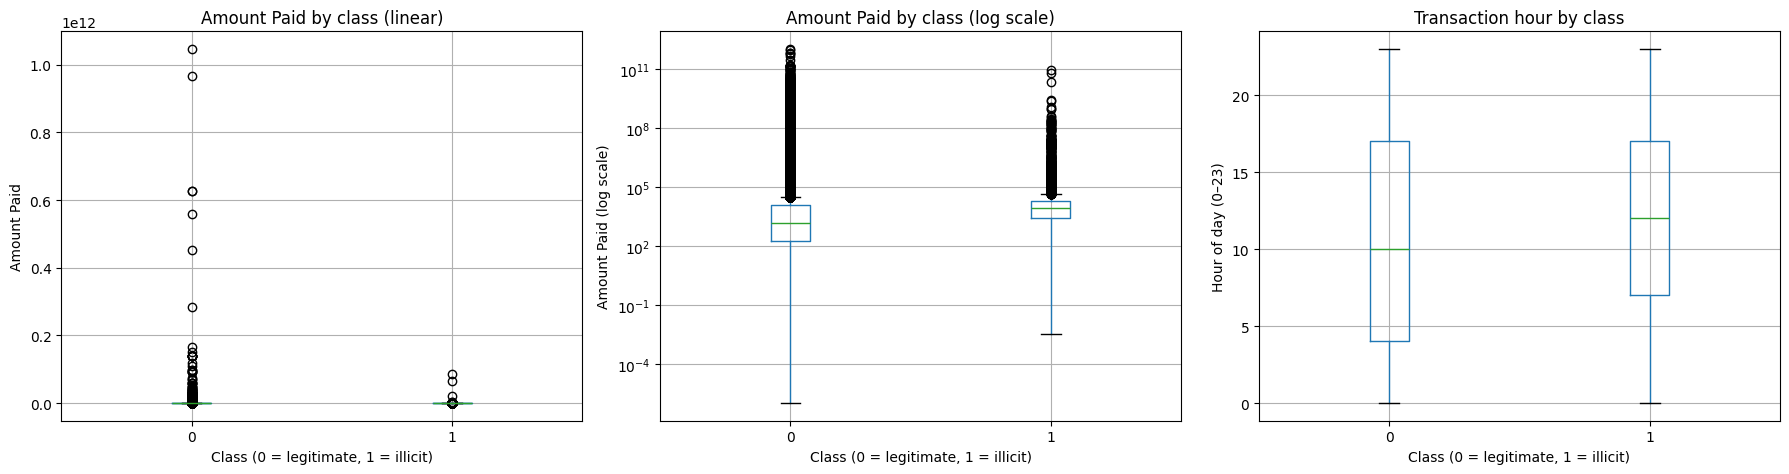

Global base rate: 0.1019%

--- Illicit rate by hour ---
       count  sum  illicit_rate_%
Hour                             
0     634726  176          0.0277
1     193728  152          0.0785
2     193143  165          0.0854
3     193249  146          0.0756
4     193166  154          0.0797
5     193900  188          0.0970
6     194456  207          0.1065
7     193336  195          0.1009
8     192921  258          0.1337
9     192952  217          0.1125
10    193229  234          0.1211
11    193500  295          0.1525
12    192972  336          0.1741
13    192521  292          0.1517
14    192787  279          0.1447
15    194871  263          0.1350
16    193407  311          0.1608
17    193154  257          0.1331
18    193321  255          0.1319
19    192824  231          0.1198
20    192809  134          0.0695
21    192192  154          0.0801
22    191836  128          0.0667
23    193345  150          0.0776

--- Business-hours feature validation (08:00–18:59) ---
   

In [ ]:
# ============================================================================
# 5. EXPLORATORY DATA ANALYSIS — distributions by class
# ============================================================================

# Parse the timestamp once and derive temporal features.
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour
df["is_business_hours"] = df["Hour"].between(8, 18).astype("int8")

# Log-scale caveat: matplotlib silently drops non-positive values on a log
# axis. Quantify them explicitly so the log-scale panel can be read safely.
n_nonpositive = (df["Amount Paid"] <= 0).sum()
print(
    f"Non-positive 'Amount Paid' values: {n_nonpositive:,} "
    f"({n_nonpositive / len(df) * 100:.4f}% of rows)\n"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 5.1 Amount by class (linear scale) ---
df.boxplot(column="Amount Paid", by=TARGET, ax=axes[0])
axes[0].set_title("Amount Paid by class (linear)")
axes[0].set_xlabel("Class (0 = legitimate, 1 = illicit)")
axes[0].set_ylabel("Amount Paid")

# --- 5.2 Amount by class (log scale) ---
df.boxplot(column="Amount Paid", by=TARGET, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Amount Paid by class (log scale)")
axes[1].set_xlabel("Class (0 = legitimate, 1 = illicit)")
axes[1].set_ylabel("Amount Paid (log scale)")

# --- 5.3 Hour of day by class ---
df.boxplot(column="Hour", by=TARGET, ax=axes[2])
axes[2].set_title("Transaction hour by class")
axes[2].set_xlabel("Class (0 = legitimate, 1 = illicit)")
axes[2].set_ylabel("Hour of day (0–23)")

plt.suptitle("")
plt.tight_layout()
plt.show()

hourly = df.groupby("Hour", observed=False)[TARGET].agg(["count", "sum", "mean"])
hourly["illicit_rate_%"] = (hourly["mean"] * 100).round(4)

business_hours_stats = (
    df.groupby("is_business_hours", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
business_hours_stats["illicit_rate_%"] = (
    business_hours_stats["mean"] * 100
).round(4)
business_hours_stats["lift_vs_base"] = (
    business_hours_stats["mean"] / BASE_RATE
).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print("--- Illicit rate by hour ---")
print(hourly[["count", "sum", "illicit_rate_%"]])

print("\n--- Business-hours feature validation (08:00–18:59) ---")
print(
    business_hours_stats[["count", "sum", "illicit_rate_%", "lift_vs_base"]]
    .rename(index={0: "Outside business hours", 1: "Business hours"})
)


### 5.1 Distributions by class

**Transaction amount.** On a linear scale, legitimate transactions contain extreme outliers (up to approximately 1×10¹²), compressing most observations and making the classes visually indistinguishable. The log-scale view reveals limited additional structure: illicit values are somewhat more concentrated in a middle range, but amount alone does not provide clean separation. `Amount Paid` is therefore retained as a weak baseline numeric input rather than treated as a strong standalone signal. Because matplotlib silently omits non-positive values on a log axis, the count of non-positive amounts is verified explicitly in the cell above rather than assumed to be zero; the log-scale panel should be read alongside that count.

**Transaction hour.** The hour-level illicit rate reveals a daily pattern that the boxplots do not show. The rate is lowest overnight and increases during the daytime, peaking at 12:00 at 0.1741%. However, the binary feature must be evaluated using the complete 08:00–18:59 group rather than the single peak hour. Across that full interval, the illicit rate is approximately **0.1410%**, or **1.38× the global base rate**. This remains a moderate and interpretable signal, but it is weaker than the previous peak-based description implied.

The pattern contradicts the original unusual-hours hypothesis: laundering in this synthetic dataset aligns more closely with normal business activity than with the early morning. This could represent attempts to blend into ordinary transaction volume, but it may also be a rule of the synthetic generator. Midnight contains substantially more records than most other hours, which is noted as an additional data-quality characteristic.


In [ ]:
# Round-value flags at different granularities
df['round_100']  = (df['Amount Paid'] % 100 == 0).astype('int8')
df['round_1000'] = (df['Amount Paid'] % 1000 == 0).astype('int8')

base = df['Is Laundering'].mean() * 100
print(f"Global base rate: {base:.4f}%\n")

for col in ['round_100', 'round_1000']:
    print(f"--- {col} ---")
    t = df.groupby(col)['Is Laundering'].agg(['count', 'sum', 'mean'])
    t['illicit_rate_%'] = (t['mean'] * 100).round(4)
    print(t[['count', 'sum', 'illicit_rate_%']])
    print()

Global base rate: 0.1019%

--- round_100 ---
             count   sum  illicit_rate_%
round_100                               
0          5077718  5176          0.1019
1              627     1          0.1595

--- round_1000 ---
              count   sum  illicit_rate_%
round_1000                               
0           5078277  5177          0.1019
1                68     0          0.0000



In [ ]:
# Leakage-safe velocity feature: number of earlier transactions by the sender.
# Sorting by time ensures that a row never uses future account activity.
# cumcount() uses no target information; the first observed transaction is zero.
df = df.sort_values("Timestamp", kind="mergesort").reset_index(drop=True)
df["sender_previous_tx_count"] = (
    df.groupby("Account", sort=False)
      .cumcount()
      .astype("int32")
)

# Non-linear bands are used only for EDA. The model receives the numeric feature.
df["previous_velocity_band"] = pd.cut(
    df["sender_previous_tx_count"],
    bins=[-1, 0, 1, 5, 20, 100, float("inf")],
    labels=["0", "1", "2-5", "6-20", "21-100", "100+"],
)

velocity_stats = (
    df.groupby("previous_velocity_band", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
velocity_stats["illicit_rate_%"] = (velocity_stats["mean"] * 100).round(4)
velocity_stats["lift_vs_base"] = (velocity_stats["mean"] / BASE_RATE).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print(
    velocity_stats[["count", "sum", "illicit_rate_%", "lift_vs_base"]]
)


Global base rate: 0.1019%

                          count   sum  illicit_rate_%  lift_vs_base
previous_velocity_band                                             
0                        496995   184          0.0370          0.36
1                        344245   625          0.1816          1.78
2-5                      579241  1648          0.2845          2.79
6-20                    1431536  1168          0.0816          0.80
21-100                  1673000   836          0.0500          0.49
100+                     553328   716          0.1294          1.27


### 5.2 Feature engineering

Each candidate feature is judged against the global illicit base rate of 0.1019%. Signals that depend on future information, simulator artifacts, sparse phenomena or redundant representations are not accepted merely because they produce attractive descriptive results.

**Payment format — kept, strongest observed signal.** ACH has an illicit rate of 0.7462% (approximately 7.3× the base rate) and contains 86.6% of all illicit labels. The entire categorical variable is retained and will be one-hot encoded with unknown-category handling. Its strength is also flagged as likely generator-dependent.

**Sender velocity — re-engineered to remove future information.** The first EDA version counted every transaction made by an account across the complete 18-day dataset. Although it did not use the target, it allowed each row to see account activity that occurred later and could cross the train/test boundary. That retrospective total is therefore not used as a model input. It is replaced by `sender_previous_tx_count`, which counts only earlier observed transactions by the sender after chronological sorting. The original 2–5 band result is retained only as an exploratory clue; the leakage-safe feature is re-evaluated in the code above before any modelling claim is made.

**Business hours — kept, moderate signal.** The binary `is_business_hours` feature represents 08:00–18:59. Its full-group illicit rate is approximately 0.1410%, or 1.38× the base rate. The 12:00 peak of 0.1741% remains an hourly finding, not the rate assigned to the binary feature.

**Same account — provisionally kept, but confounded.** Transfers between different accounts have a higher illicit rate than same-account records. However, every `Reinvestment` transaction is a same-account transaction and that payment format contains no illicit labels, so much of the separation may be generated by payment format. The feature is retained provisionally and must prove incremental value beyond one-hot-encoded `Payment Format`.

**Same bank — excluded after refinement.** `same_bank` was initially retained as a weak candidate, but it is highly redundant with the more granular `same_account` flag. Keeping both would add limited independent information, so `same_bank` is removed from the final input set.

**Cross-currency — excluded as a generator artifact.** All 72,170 cross-currency transactions are labelled legitimate. This unrealistically perfect negative rule would not be expected to generalise.

**Round-value flags — excluded because the phenomenon is effectively absent.** Only 627 amounts are multiples of 100 and only 68 are multiples of 1,000 in 5.08 million records. The sample is too sparse to support the hypothesis.

The feature set is now considered closed for the first modelling cycle. Additional feature testing before the baselines would be analysis without delivery; the next step is to determine whether these inputs generalise beyond descriptive EDA.


In [ ]:
# Same account (origin == destination)
df["same_account"] = (df["Account"] == df["Account.1"]).astype("int8")

same_account_stats = (
    df.groupby("same_account", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
same_account_stats["illicit_rate_%"] = (
    same_account_stats["mean"] * 100
).round(4)
same_account_stats["%_of_all_tx"] = (
    same_account_stats["count"] / len(df) * 100
).round(2)
same_account_stats["lift_vs_base"] = (
    same_account_stats["mean"] / BASE_RATE
).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print("--- Illicit rate by same-account flag ---")
print(
    same_account_stats[
        ["count", "%_of_all_tx", "sum", "illicit_rate_%", "lift_vs_base"]
    ].rename(index={0: "Different accounts", 1: "Same account"})
)

print("\n--- same_account vs Payment Format ---")
print(pd.crosstab(df["same_account"], df["Payment Format"]))

# Reproduce the redundancy checks cited in the final selection.
correlation_check = df[
    ["same_bank", "same_account", "Amount Paid", "Amount Received"]
].corr()

print("\n--- Redundancy checks ---")
print(f"Correlation: same_bank vs same_account = {correlation_check.loc['same_bank', 'same_account']:.3f}")
print(f"Correlation: Amount Paid vs Amount Received = {correlation_check.loc['Amount Paid', 'Amount Received']:.3f}")


Global base rate: 0.1019%

--- Illicit rate by same-account flag ---
                      count  %_of_all_tx   sum  illicit_rate_%  lift_vs_base
same_account                                                                
Different accounts  4487133        88.36  5166          0.1151          1.13
Same account         591212        11.64    11          0.0019          0.02

--- same_account vs Payment Format ---
Payment Format     ACH  Bitcoin    Cash   Cheque  Credit Card  Reinvestment  \
same_account                                                                  
0               529450   119774  489436  1858265      1319148             0   
1                71347    26317    1455     6066         4176        481056   

Payment Format    Wire  
same_account            
0               171060  
1                  795  

--- Redundancy checks ---
Correlation: same_bank vs same_account = 0.914
Correlation: Amount Paid vs Amount Received = 0.843


### 5.3 Additional visual diagnostics

The assignment requests visual evidence alongside the statistical summaries. To complement the boxplots, this subsection adds:

- a class-conditional histogram of log-transformed transaction amounts;
- a sampled scatterplot of amount versus prior sender activity;
- a correlation matrix for the numeric and binary modelling variables.

All laundering records are retained in the visual sample, while legitimate transactions are sampled to keep the plots readable. The correlation matrix is descriptive only: low linear correlation does not rule out non-linear predictive signal.


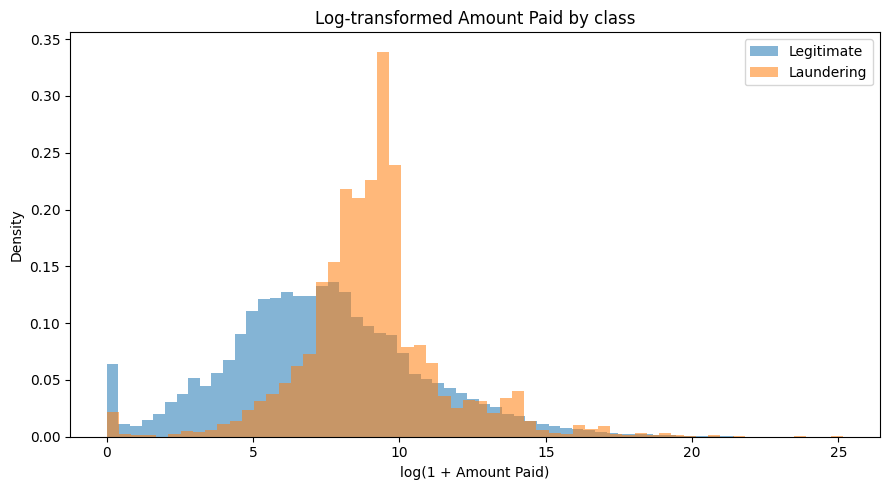

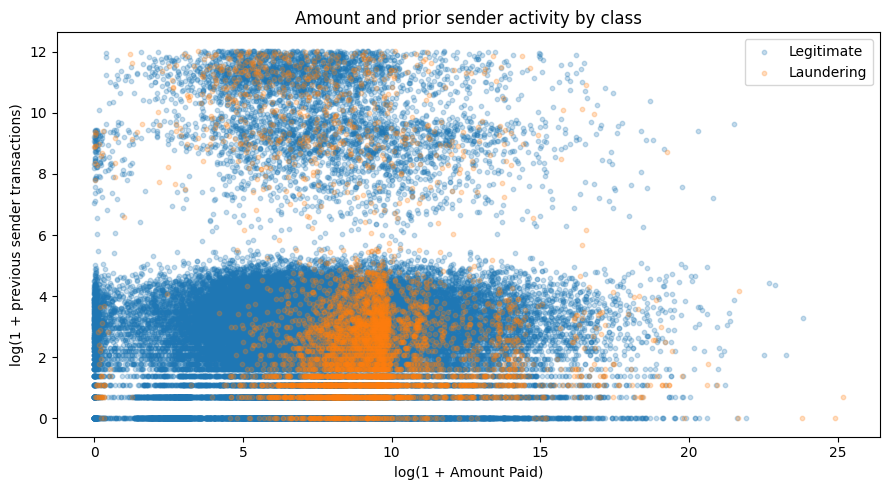

Selected-feature correlation matrix:


,Amount Paid,sender_previous_tx_count,is_business_hours,same_account,Is Laundering
Amount Paid,1.0000,-0.0010,0.0005,-0.0008,0.0012
sender_previous_tx_count,-0.0010,1.0000,0.0203,-0.0775,0.0026
is_business_hours,0.0005,0.0203,1.0000,-0.1046,0.0104
same_account,-0.0008,-0.0775,-0.1046,1.0000,-0.0114
Is Laundering,0.0012,0.0026,0.0104,-0.0114,1.0000


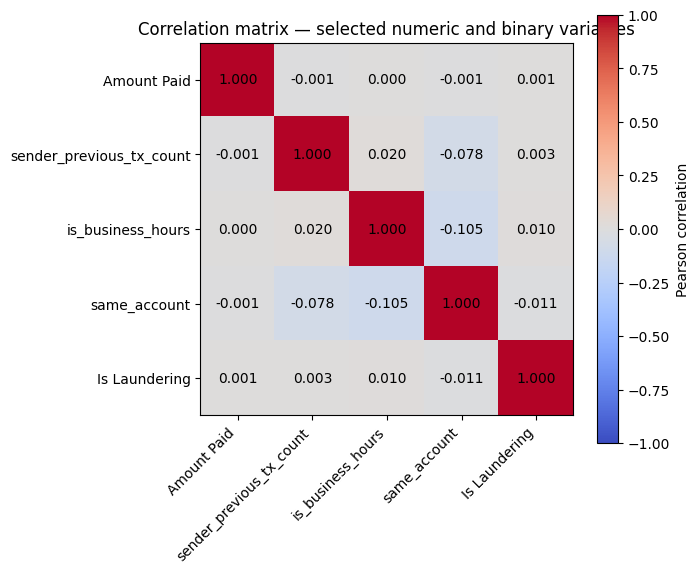

In [ ]:
# Keep every illicit transaction and sample legitimate records for readable plots.
legitimate_visual_sample = df[df[TARGET] == 0].sample(
    n=min(50_000, int((df[TARGET] == 0).sum())),
    random_state=RANDOM_STATE,
)

illicit_visual_sample = df[df[TARGET] == 1]

eda_visual_sample = pd.concat(
    [legitimate_visual_sample, illicit_visual_sample],
    ignore_index=True,
)

eda_visual_sample["log_amount_paid"] = np.log1p(
    eda_visual_sample["Amount Paid"].clip(lower=0)
)
eda_visual_sample["log_sender_previous_tx_count"] = np.log1p(
    eda_visual_sample["sender_previous_tx_count"]
)

# Histogram
plt.figure(figsize=(9, 5))

for class_value, class_label in [(0, "Legitimate"), (1, "Laundering")]:
    class_data = eda_visual_sample.loc[
        eda_visual_sample[TARGET] == class_value,
        "log_amount_paid",
    ]

    plt.hist(
        class_data,
        bins=60,
        density=True,
        alpha=0.55,
        label=class_label,
    )

plt.title("Log-transformed Amount Paid by class")
plt.xlabel("log(1 + Amount Paid)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Scatterplot
plt.figure(figsize=(9, 5))

for class_value, class_label in [(0, "Legitimate"), (1, "Laundering")]:
    class_data = eda_visual_sample[
        eda_visual_sample[TARGET] == class_value
    ]

    plt.scatter(
        class_data["log_amount_paid"],
        class_data["log_sender_previous_tx_count"],
        s=10,
        alpha=0.25,
        label=class_label,
    )

plt.title("Amount and prior sender activity by class")
plt.xlabel("log(1 + Amount Paid)")
plt.ylabel("log(1 + previous sender transactions)")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation matrix for numeric/binary modelling variables and the target.
correlation_features = [
    "Amount Paid",
    "sender_previous_tx_count",
    "is_business_hours",
    "same_account",
    TARGET,
]

selected_correlation_matrix = df[correlation_features].corr()

print("Selected-feature correlation matrix:")
display(selected_correlation_matrix.round(4))

plt.figure(figsize=(7, 6))
correlation_image = plt.imshow(
    selected_correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(correlation_features)),
    correlation_features,
)

for row_index in range(len(correlation_features)):
    for column_index in range(len(correlation_features)):
        plt.text(
            column_index,
            row_index,
            f"{selected_correlation_matrix.iloc[row_index, column_index]:.3f}",
            ha="center",
            va="center",
        )

plt.colorbar(correlation_image, label="Pearson correlation")
plt.title("Correlation matrix — selected numeric and binary variables")
plt.tight_layout()
plt.show()


#### Interpretation — Additional visual diagnostics

The log-transformed amount distributions overlap substantially, reinforcing the earlier conclusion that `Amount Paid` has limited standalone separation.

The sampled scatterplot does not reveal a clean linear boundary between legitimate and laundering transactions. Illicit observations remain embedded within the much larger legitimate population, which supports evaluating multivariate models rather than relying on a single visual rule.

The correlation matrix quantifies only linear pairwise relationships. Small target correlations are therefore not evidence that the selected variables are useless: payment format is categorical, sender activity is non-monotonic, and tree-based models can learn thresholds and interactions that Pearson correlation cannot represent.


In [ ]:
# Illicit rate by sending bank — descriptive analysis only.
bank_stats = df.groupby("From Bank")[TARGET].agg(["count", "sum", "mean"])
bank_stats["illicit_rate_%"] = (bank_stats["mean"] * 100).round(4)
bank_stats["lift_vs_base"] = (bank_stats["mean"] / BASE_RATE).round(2)

# Minimum support reduces, but does not eliminate, small-sample instability.
reliable_banks = (
    bank_stats[bank_stats["count"] >= 1_000]
    .sort_values("mean", ascending=False)
)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print(
    f"Banks with at least 1,000 transactions: "
    f"{len(reliable_banks)} of {len(bank_stats)} total\n"
)
print("--- Top 10 banks by illicit rate, subject to minimum support ---")
print(
    reliable_banks[["count", "sum", "illicit_rate_%", "lift_vs_base"]]
    .head(10)
)

print("\n--- Distribution of illicit activity across banks ---")
print(f"Total sending banks: {df['From Bank'].nunique():,}")
print(f"Banks with at least one illicit transaction: {(bank_stats['sum'] > 0).sum():,}")


Global base rate: 0.1019%

Banks with at least 1,000 transactions: 802 of 30470 total

--- Top 10 banks by illicit rate, subject to minimum support ---
           count  sum  illicit_rate_%  lift_vs_base
From Bank                                          
148350      1362   31          2.2761         22.33
213952      2165   33          1.5242         14.95
11128       1166   14          1.2007         11.78
249176      1454   15          1.0316         10.12
19329       2779   25          0.8996          8.82
15231       3780   33          0.8730          8.56
48309       3160   27          0.8544          8.38
7548        2325   19          0.8172          8.02
210431      2140   17          0.7944          7.79
214615      2173   17          0.7823          7.67

--- Distribution of illicit activity across banks ---
Total sending banks: 30,470
Banks with at least one illicit transaction: 1,021


In [ ]:
# Accounts that appear most in illicit transactions (as sender)
illicit = df[df['Is Laundering'] == 1]
print(f"Total illicit transactions: {len(illicit)}")
print(f"Unique sending accounts in illicit tx: {illicit['Account'].nunique()}")
print(f"Unique receiving accounts in illicit tx: {illicit['Account.1'].nunique()}")

print("\n--- Top 10 sending accounts by illicit count ---")
print(illicit['Account'].value_counts().head(10))

print("\n--- Top 10 receiving accounts by illicit count ---")
print(illicit['Account.1'].value_counts().head(10))

Total illicit transactions: 5177
Unique sending accounts in illicit tx: 3376
Unique receiving accounts in illicit tx: 3984

--- Top 10 sending accounts by illicit count ---
Account
100428660    243
1004286A8    158
80266F880     29
100428978     29
100428810     26
812D22980     25
100428738     23
1004286F0     21
811C597B0     21
100428780     21
Name: count, dtype: int64

--- Top 10 receiving accounts by illicit count ---
Account.1
811C599A0    31
8021353D0    28
811C597B0    23
80266F880    22
811ED7DF0    20
812A09CF0    19
811D80C30    18
811B83280    17
8079DDC30    16
80AEBECB0    16
Name: count, dtype: int64


### 5.4 Network structure of illicit activity (EDA insight, not a feature)

The concentration of illicit labels across banks and accounts was examined to identify hypotheses for later graph analysis. These identifiers are not used directly as model inputs.

**Banks — heterogeneous rates, but no defensible ID feature.** Illicit labels appear in 1,021 of 30,470 sending banks. Among banks with at least 1,000 transactions, the highest observed illicit rate is 2.2761%, approximately **22.3× the global base rate**. This concentration is descriptively important, but each bank is represented by a synthetic identifier and even the leading bank contains only 31 illicit records. Encoding bank IDs would invite memorisation of the generator's entities and would generalise poorly to unseen institutions. Bank identity is therefore excluded despite the observed heterogeneity.

**Accounts — concentration consistent with repeated circulation.** The 5,177 illicit transactions originate from 3,376 unique sending accounts. Two accounts alone send 401 illicit transactions, close to 8% of all illicit labels. Several accounts also appear among both the most frequent illicit senders and receivers. This pattern is **consistent with** repeated circulation among a subset of accounts, but top-10 overlap alone does not prove a classic layering topology. Demonstrating cycles, components, reciprocity or centrality requires an explicit graph analysis.

The near-sequential account prefixes and concentrated activity may themselves be simulator artifacts. The defensible conclusion is therefore narrower: the observations motivate a future NetworkX extension with fan-in, fan-out, cycle and centrality features, while account and bank IDs remain excluded from the present transaction-level model.


In [ ]:
# Retrospective account-lifespan hypothesis (EDA only; not a model feature)
df["Date"] = df["Timestamp"].dt.date

# Number of distinct active days across the complete observed window.
days_per_account = df.groupby("Account")["Date"].transform("nunique")
df["account_n_days"] = days_per_account
df["single_day_account"] = (df["account_n_days"] == 1).astype("int8")

single_day_stats = (
    df.groupby("single_day_account", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
single_day_stats["illicit_rate_%"] = (single_day_stats["mean"] * 100).round(4)
single_day_stats["%_of_all_tx"] = (
    single_day_stats["count"] / len(df) * 100
).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print("--- Illicit rate by single-day vs multi-day accounts ---")
print(
    single_day_stats[["count", "%_of_all_tx", "sum", "illicit_rate_%"]]
    .rename(index={0: "Multi-day account", 1: "Single-day account"})
)

# Contrast the misleading volume-based reading with the correct rate-based view.
illicit = df[df[TARGET] == 1]
print("\n--- Of illicit transactions, share from each account-lifespan group ---")
print((illicit["single_day_account"].value_counts(normalize=True) * 100).round(2))


Global base rate: 0.1019%

--- Illicit rate by single-day vs multi-day accounts ---
                      count  %_of_all_tx   sum  illicit_rate_%
single_day_account                                            
Multi-day account   4748113         93.5  4885          0.1029
Single-day account   330232          6.5   292          0.0884

--- Of illicit transactions, share from each account-lifespan group ---
single_day_account
0    94.36
1     5.64
Name: proportion, dtype: float64


### 5.5 Final feature selection

After testing the candidate variables against the global illicit base rate of 0.1019%, five inputs are retained for the first modelling cycle. Selection is based on illicit rate, information availability at prediction time, redundancy and generalisation risk—not raw counts or attractive in-sample separation alone.

#### Selected model inputs

| Feature | Type | Observed evidence | Decision rationale |
|---|---|---|---|
| `Payment Format` | categorical, one-hot encoded | ACH: 0.7462% illicit rate, 7.3× the base rate | Strongest observed signal; all categories are encoded and unknown test categories are ignored safely |
| `sender_previous_tx_count` | numeric | Recomputed above using only earlier sender activity | Leakage-safe replacement for the retrospective total account count; supports non-linear velocity effects |
| `is_business_hours` | binary | 08:00–18:59: approximately 0.1410%, 1.38× the base rate | Moderate temporal signal; uses the full binary group rather than the 12:00 peak |
| `same_account` | binary | Different accounts: 0.1151%, approximately 1.13× the base rate | Weak and confounded with `Reinvestment`; retained provisionally to test incremental value beyond payment format |
| `Amount Paid` | numeric | Weak standalone separation | Retained as a baseline monetary input and to allow interactions with other variables |

#### Excluded variables

| Feature | Reason for exclusion |
|---|---|
| `is_cross_currency` | Generator artifact: zero illicit labels in 72,170 cross-currency records, creating an unrealistically perfect negative rule |
| `round_100`, `round_1000` | The hypothesised phenomenon is effectively absent and too sparse to support a stable conclusion |
| `single_day_account` | Illicit rate is approximately equal to or below the base rate; the apparent concentration was a volume artifact, and the feature is retrospective |
| `same_bank` | Highly redundant with the more granular `same_account` flag; the measured correlation is reproduced above |
| `Amount Received` | Highly redundant with `Amount Paid`; the measured correlation is reproduced above |
| Account and bank identifiers | High risk of memorising synthetic entities and failing on unseen accounts or institutions |

#### Closing assessment

The data strongly support payment format and provide weaker evidence for business hours and movement between different accounts. The initial unusual-hours direction is rejected, while velocity remains a plausible non-linear signal after being rebuilt so that each transaction uses only prior sender activity.

Pairwise linear correlation with the target is not used as a feature-selection gate. With an extremely rare binary target and non-monotonic relationships, near-zero Pearson correlation does not imply absence of predictive information. The modelling stage therefore compares a Logistic Regression baseline with tree-based models that can learn thresholds and interactions; it does not assume in advance that linear methods are invalid.

Finally, ACH concentration, zero-illicit categories, sequential account identifiers and other strong patterns may reflect the synthetic generator. Model performance will be reported as performance on this benchmark, not as evidence of production readiness for real financial institutions.


## 6. Data Preparation and Leakage Controls

The first model cycle uses the five selected inputs and a stratified 70/30 train/test split. Stratification is required because only 0.1019% of records are positive; without it, small prevalence differences could distort comparisons between models.

Preprocessing is **defined but not fitted in isolation**. It will be fitted inside each model pipeline, ensuring that category learning and numeric scaling use training data only. Two preprocessors are defined: one with scaling for Logistic Regression and one without scaling for tree-based models.

The random stratified split is appropriate for the first benchmark but does not guarantee entity independence: the same account can appear in both partitions. Because the data cover only 18 days, a temporal or account-grouped holdout is documented as a later robustness test rather than silently claimed as solved.

In [ ]:
# ============================================================================
# 6. DATA PREPARATION
# ============================================================================

FEATURES = [
    "Payment Format",
    "Amount Paid",
    "sender_previous_tx_count",
    "is_business_hours",
    "same_account",
]

X = df[FEATURES].copy()
y = df[TARGET].astype("int8")

# Reduce memory usage before splitting the 5.08M-row dataset.
X["Payment Format"] = X["Payment Format"].astype("category")
X["Amount Paid"] = X["Amount Paid"].astype("float32")
X["sender_previous_tx_count"] = X["sender_previous_tx_count"].astype("int32")
X["is_business_hours"] = X["is_business_hours"].astype("int8")
X["same_account"] = X["same_account"].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X shape:       {X.shape}")
print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.4%} ({y_train.sum():,} positives)")
print(f"Test positive rate:  {y_test.mean():.4%} ({y_test.sum():,} positives)")


X shape:       (5078345, 5)
Training set:  (3554841, 5)
Test set:      (1523504, 5)
Train positive rate: 0.1019% (3,624 positives)
Test positive rate:  0.1019% (1,553 positives)


### 6.1 Column groups and preprocessing

- `Payment Format` is categorical and receives one-hot encoding with `handle_unknown="ignore"`, preventing an unseen test category from causing an error.
- `Amount Paid` and `sender_previous_tx_count` are numeric. They are standardised for Logistic Regression but passed through unchanged for tree models.
- `is_business_hours` and `same_account` are binary and pass through unchanged.
- `sparse_threshold=1.0` preserves a sparse combined matrix after one-hot encoding, reducing memory pressure on the full dataset.

Each preprocessor holds its **own** `OneHotEncoder` instance (created by a small factory function) instead of sharing one object: sklearn fits estimators in place, so a shared instance would be silently mutated by whichever pipeline trains first.

Neither transformer is fitted here. Fitting occurs only when its enclosing model pipeline is trained on `X_train` or on a training fold during cross-validation.

In [ ]:
categorical_features = ["Payment Format"]
numeric_features = ["Amount Paid", "sender_previous_tx_count"]
binary_features = ["is_business_hours", "same_account"]


def make_categorical_encoder():
    """Return a fresh OneHotEncoder instance.

    Each preprocessor receives its own encoder object. Sharing a single
    mutable estimator instance across two ColumnTransformers is a footgun:
    sklearn fits estimators in place, so training one pipeline would silently
    mutate the encoder referenced by the other.
    """
    return OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        dtype=np.float32,
    )


linear_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", make_categorical_encoder(), categorical_features),
        ("numeric", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", make_categorical_encoder(), categorical_features),
        ("numeric", "passthrough", numeric_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

print("✓ Linear and tree preprocessors defined (independent encoder instances)")
print("✓ No transformer has been fitted outside a model pipeline")

✓ Linear and tree preprocessors defined (independent encoder instances)
✓ No transformer has been fitted outside a model pipeline


## 7. Classification Models

Modelling starts with two deliberately simple references before any ensemble:

1. `DummyClassifier(strategy="most_frequent")` — a naive baseline proving that approximately 99.9% accuracy can coexist with zero illicit recall (Section 7.1).
2. Logistic Regression with `class_weight="balanced"` — the first real, interpretable linear baseline (Section 7.2), followed by an unweighted ablation that isolates what class weighting actually changes (Section 7.3).

**Average Precision (AP)** is the principal comparison metric throughout, complemented by the confusion matrix, the classification report and, in Section 8, recall at an explicit alert-budget threshold. ROC-AUC is deliberately not used as a headline number because it appears optimistic under extreme imbalance.

**Imbalance-handling scope.** Class weighting is evaluated first. Resampling follows in Section 7.4, with random undersampling as the primary experiment: naive SMOTE applied after one-hot encoding can create fractional category combinations and is computationally expensive at 3.5M training rows. If oversampling is tested, it uses a mixed-data-aware strategy (`SMOTENC`) inside an `imblearn` pipeline, as a secondary experiment.

In [ ]:
# Baseline estimators are assembled here and fitted in Sections 7.1–7.2.
dummy_baseline = DummyClassifier(strategy="most_frequent")

logistic_baseline = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print("✓ Dummy and Logistic Regression baselines assembled")


✓ Dummy and Logistic Regression baselines assembled


In [ ]:
# All dependencies (perf_counter, numpy, pandas, sklearn metrics) are
# imported once in the setup cell at the top of the notebook.


def fit_and_evaluate_model(
    model_name,
    estimator,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.50,
):
    """Fit and evaluate a binary classifier using a fixed decision threshold."""

    fit_start = perf_counter()
    estimator.fit(X_train, y_train)
    fit_seconds = perf_counter() - fit_start

    score_start = perf_counter()

    positive_class_index = np.flatnonzero(estimator.classes_ == 1)[0]

    y_score = estimator.predict_proba(X_test)[:, positive_class_index].astype(
        np.float32
    )

    y_pred = (y_score >= threshold).astype(np.int8)

    score_seconds = perf_counter() - score_start

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1],
    ).ravel()

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "average_precision": average_precision_score(y_test, y_score),
        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "alerts": int(y_pred.sum()),
        "alert_rate_pct": float(y_pred.mean() * 100),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "fit_seconds": fit_seconds,
        "score_seconds": score_seconds,
    }

    confusion_table = pd.DataFrame(
        [
            [tn, fp],
            [fn, tp],
        ],
        index=[
            "Actual legitimate",
            "Actual laundering",
        ],
        columns=[
            "Predicted legitimate",
            "Predicted laundering",
        ],
    )

    print(f"\n{'=' * 70}")
    print(model_name)
    print(f"{'=' * 70}")
    print(f"Decision threshold: {threshold:.2f}")
    print(f"Training time:     {fit_seconds:.2f} seconds")
    print(f"Scoring time:      {score_seconds:.2f} seconds")
    print(f"Accuracy:          {metrics['accuracy']:.6f}")
    print(f"Average Precision: {metrics['average_precision']:.6f}")
    print(f"Precision:         {metrics['precision']:.6f}")
    print(f"Recall:            {metrics['recall']:.6f}")
    print(f"F1-score:          {metrics['f1_score']:.6f}")
    print(
        f"Alerts generated:  {metrics['alerts']:,} "
        f"({metrics['alert_rate_pct']:.4f}% of test transactions)"
    )

    print("\nConfusion matrix:")
    try:
        display(confusion_table)  # rich rendering inside Jupyter/Colab
    except NameError:
        # display() only exists in IPython environments; fall back to plain
        # text so this function can be reused from src/ scripts (Phase 2).
        print(confusion_table.to_string())

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=[
                "Legitimate",
                "Laundering",
            ],
            digits=6,
            zero_division=0,
        )
    )

    return estimator, metrics, y_pred, y_score

### 7.1 Naive baseline — Dummy Classifier

Before training predictive models, a `DummyClassifier` using the `most_frequent` strategy is evaluated as a naive reference. This classifier does not learn from the input features. Instead, it predicts the majority class—legitimate—for every transaction.

The purpose of this baseline is not to obtain useful predictions, but to demonstrate why accuracy alone is misleading under extreme class imbalance. Since approximately 99.9% of the transactions are legitimate, a classifier that never detects laundering can still achieve nearly 100% accuracy.

The remaining metrics are therefore necessary to expose the model's actual performance on the minority class:

* **Recall** measures how many laundering transactions are detected.
* **Precision** measures how many generated alerts are truly illicit.
* **F1-score** summarises the balance between precision and recall at a fixed threshold.
* **Average Precision** evaluates the model's ability to rank illicit transactions above legitimate ones across different decision thresholds.

For the remainder of the project, Average Precision is used as the primary model-comparison metric, while precision, recall, and alert volume are used to assess operational usefulness.


In [ ]:
(
    dummy_baseline,
    dummy_metrics,
    dummy_predictions,
    dummy_scores,
) = fit_and_evaluate_model(
    model_name="Dummy Classifier",
    estimator=dummy_baseline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)


Dummy Classifier
Decision threshold: 0.50
Training time:     0.06 seconds
Scoring time:      0.00 seconds
Accuracy:          0.998981
Average Precision: 0.001019
Precision:         0.000000
Recall:            0.000000
F1-score:          0.000000
Alerts generated:  0 (0.0000% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1521951,0
Actual laundering,1553,0



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.998981  1.000000  0.999490   1521951
  Laundering   0.000000  0.000000  0.000000      1553

    accuracy                       0.998981   1523504
   macro avg   0.499490  0.500000  0.499745   1523504
weighted avg   0.997962  0.998981  0.998471   1523504



#### Dummy Classifier results

The Dummy Classifier achieved an accuracy of **99.8981%**, despite predicting every transaction as legitimate. This high value is caused entirely by the extreme class imbalance: legitimate transactions account for 99.8981% of the test set.

The confusion matrix reveals the model's actual behaviour. All **1,521,951 legitimate transactions** were classified correctly, but all **1,553 laundering transactions** were incorrectly classified as legitimate. Consequently, the model generated no alerts and obtained **0 recall, 0 precision, and 0 F1-score** for the laundering class.

This result does not indicate that precision, recall, or F1-score are inappropriate. On the contrary, these metrics correctly reveal that the model has no practical value for laundering detection. Accuracy alone hides this failure because correct predictions from the majority class dominate the calculation.

The model's **Average Precision of 0.001019** is equal to the positive-class prevalence of approximately **0.1019%**. This indicates that the classifier has no ability to rank laundering transactions above legitimate ones and performs at the dataset's base-rate level.

The Dummy Classifier therefore establishes a minimum baseline rather than a competitive model. Every subsequent classifier must outperform it in Average Precision and detect at least some illicit transactions while maintaining a manageable alert volume.


### 7.2 Linear baseline — Logistic Regression

A Logistic Regression is used as the first predictive baseline because it is fast, interpretable, and suitable for binary classification. Unlike the Dummy Classifier, it learns relationships between the selected transaction features and the laundering target.

The model uses `class_weight="balanced"` to increase the importance of the rare laundering class during training. Without this adjustment, the extreme class imbalance could lead the classifier to favour the legitimate class almost exclusively.

The preprocessing and classifier are contained in a single pipeline. This ensures that one-hot encoding and numerical scaling are fitted only on the training data, preventing data leakage.

The default decision threshold of 0.50 is retained for this initial evaluation. Threshold optimisation will be performed later because the balanced class weights may affect the interpretation and calibration of the predicted probabilities.

In [ ]:
(
    logistic_baseline,
    logistic_metrics,
    logistic_predictions,
    logistic_scores,
) = fit_and_evaluate_model(
    model_name="Logistic Regression — Balanced",
    estimator=logistic_baseline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)


Logistic Regression — Balanced
Decision threshold: 0.50
Training time:     10.01 seconds
Scoring time:      0.35 seconds
Accuracy:          0.874521
Average Precision: 0.008381
Precision:         0.007286
Recall:            0.902769
F1-score:          0.014456
Alerts generated:  192,418 (12.6300% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1330935,191016
Actual laundering,151,1402



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.999887  0.874493  0.932995   1521951
  Laundering   0.007286  0.902769  0.014456      1553

    accuracy                       0.874521   1523504
   macro avg   0.503586  0.888631  0.473726   1523504
weighted avg   0.998875  0.874521  0.932059   1523504



In [ ]:
test_positive_count = int(y_test.sum())
test_negative_count = int((y_test == 0).sum())

assert (
    logistic_metrics["true_positives"]
    + logistic_metrics["false_negatives"]
    == test_positive_count
)

assert (
    logistic_metrics["true_negatives"]
    + logistic_metrics["false_positives"]
    == test_negative_count
)

assert logistic_metrics["average_precision"] >= dummy_metrics["average_precision"]

print("✓ Logistic Regression evaluation checks passed")

✓ Logistic Regression evaluation checks passed


#### Logistic Regression results

The balanced Logistic Regression detected **1,402 of the 1,553 laundering transactions** in the test set, achieving a laundering recall of **90.28%**. This represents a substantial improvement over the Dummy Classifier, which failed to detect any positive cases.

The model's Average Precision increased from the Dummy baseline of `0.001019` to `0.008381`. This is approximately 8.2 times the positive-class base rate, indicating that the selected features provide meaningful ranking information even though their individual linear correlations with the target are close to zero.

However, this high recall was achieved at a considerable operational cost. At the default threshold of 0.50, the model generated **192,418 alerts**, representing **12.63% of all test transactions**. Only 1,402 of these alerts corresponded to actual laundering cases, while 191,016 were false positives. The resulting laundering precision was therefore only **0.73%**, equivalent to approximately one true laundering case for every 137 alerts reviewed.

Accuracy decreased from 99.90% for the Dummy Classifier to 87.45% for the Logistic Regression. This reduction does not represent a loss of practical value. The Dummy Classifier obtained high accuracy by predicting every transaction as legitimate, whereas the Logistic Regression deliberately accepts more false positives in order to detect the minority class.

The results show that the linear model successfully extracts predictive signal and provides a meaningful baseline. Nevertheless, its alert volume and false-positive rate would be operationally impractical at the default threshold. Model comparison will therefore focus primarily on Average Precision, while threshold tuning will later evaluate the trade-off between laundering recall, alert precision, and analyst workload.


### 7.3 Ablation — Logistic Regression without class weighting

To isolate the effect of `class_weight="balanced"`, the identical pipeline is retrained without weighting. Comparing the two answers a precise question: does class weighting change the model's *ranking* of transactions by risk, or only the position of its decision threshold?

In [ ]:
# `clone` is imported in the setup cell.
logistic_unweighted = Pipeline(
    steps=[
        ("preprocessor", clone(linear_preprocessor)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

(
    logistic_unweighted,
    logistic_unweighted_metrics,
    logistic_unweighted_predictions,
    logistic_unweighted_scores,
) = fit_and_evaluate_model(
    model_name="Logistic Regression — Unweighted",
    estimator=logistic_unweighted,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)


Logistic Regression — Unweighted
Decision threshold: 0.50
Training time:     3.81 seconds
Scoring time:      0.36 seconds
Accuracy:          0.998981
Average Precision: 0.009182
Precision:         0.000000
Recall:            0.000000
F1-score:          0.000000
Alerts generated:  0 (0.0000% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1521951,0
Actual laundering,1553,0



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.998981  1.000000  0.999490   1521951
  Laundering   0.000000  0.000000  0.000000      1553

    accuracy                       0.998981   1523504
   macro avg   0.499490  0.500000  0.499745   1523504
weighted avg   0.997962  0.998981  0.998471   1523504



#### Unweighted Logistic Regression results

The unweighted Logistic Regression generated no alerts at the default 0.50 threshold. Consequently, its laundering precision, recall, and F1-score were all zero, while its accuracy returned to the misleading Dummy Classifier level of 99.8981%.

However, its **Average Precision of 0.009182** was slightly higher than the balanced model's value of 0.008381. This shows that the unweighted model contains useful ranking information even though none of its predicted scores crosses the default classification threshold.

The result illustrates the distinction between ranking performance and threshold-based classification. Average Precision evaluates how effectively transactions are ordered by risk across multiple thresholds, whereas precision, recall, and the confusion matrix describe performance at one specific operating threshold.

Class weighting changes the optimisation objective and shifts the score distribution, causing substantially more transactions to exceed the 0.50 threshold. It may also alter the fitted coefficients and transaction ranking. The current results alone are not sufficient to conclude that the balanced and unweighted models produce nearly identical rankings; this will be examined later through precision–recall curves and threshold analysis.

The practical conclusion is that 0.50 is not an appropriate automatically selected operating threshold for this problem. Model ranking should first be compared using Average Precision, after which the final threshold should be selected according to an explicit alert budget and the resulting precision–recall trade-off.


In [ ]:
baseline_results = pd.DataFrame(
    [
        dummy_metrics,
        logistic_unweighted_metrics,
        logistic_metrics,
    ]
)

baseline_comparison_columns = [
    "model",
    "threshold",
    "accuracy",
    "average_precision",
    "precision",
    "recall",
    "f1_score",
    "alerts",
    "alert_rate_pct",
    "true_positives",
    "false_positives",
    "false_negatives",
    "true_negatives",
    "fit_seconds",
    "score_seconds",
]

baseline_results = (
    baseline_results[baseline_comparison_columns]
    .sort_values(
        by="average_precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

with pd.option_context(
    "display.float_format",
    "{:,.6f}".format,
):
    display(baseline_results)

,model,threshold,accuracy,average_precision,precision,recall,f1_score,alerts,alert_rate_pct,true_positives,false_positives,false_negatives,true_negatives,fit_seconds,score_seconds
0,Logistic Regression — Unweighted,0.500000,0.998981,0.009182,0.000000,0.000000,0.000000,0,0.000000,0,0,1553,1521951,3.808025,0.360627
1,Logistic Regression — Balanced,0.500000,0.874521,0.008381,0.007286,0.902769,0.014456,192418,12.629964,1402,191016,151,1330935,10.013025,0.353585
2,Dummy Classifier,0.500000,0.998981,0.001019,0.000000,0.000000,0.000000,0,0.000000,0,0,1553,1521951,0.064209,0.004701


### 7.4 Non-linear baseline — Random Forest

Random Forest is introduced as the first non-linear model. Unlike Logistic Regression, decision trees can learn thresholds, interactions, and non-monotonic relationships without requiring them to be specified manually.

This capability is particularly relevant to `sender_previous_tx_count`, whose exploratory relationship with illicit risk was not monotonic. The model also allows the effect of payment format to interact with transaction amount, business hours, and account relationships.

The initial configuration is deliberately bounded to control training time and memory usage on the 3.55-million-row training set. It is intended as a reproducible baseline rather than a fully tuned model. Class imbalance is addressed using `class_weight="balanced_subsample"`, which recalculates class weights for each bootstrap sample.

Numerical variables are not standardised because tree splits are insensitive to feature scale. Categorical encoding remains inside the pipeline and is fitted only on the training data.


In [ ]:
random_forest_weighted = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor),
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=80,
                max_depth=12,
                min_samples_leaf=20,
                max_features="sqrt",
                max_samples=0.25,
                class_weight="balanced_subsample",
                bootstrap=True,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

(
    random_forest_weighted,
    random_forest_metrics,
    random_forest_predictions,
    random_forest_scores,
) = fit_and_evaluate_model(
    model_name="Random Forest — Balanced Subsample",
    estimator=random_forest_weighted,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)


Random Forest — Balanced Subsample
Decision threshold: 0.50
Training time:     166.60 seconds
Scoring time:      3.37 seconds
Accuracy:          0.943904
Average Precision: 0.032510
Precision:         0.014702
Recall:            0.818416
F1-score:          0.028885
Alerts generated:  86,452 (5.6746% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1436770,85181
Actual laundering,282,1271



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.999804  0.944032  0.971118   1521951
  Laundering   0.014702  0.818416  0.028885      1553

    accuracy                       0.943904   1523504
   macro avg   0.507253  0.881224  0.500001   1523504
weighted avg   0.998800  0.943904  0.970157   1523504



#### Random Forest results

The balanced Random Forest detected **1,271 of the 1,553 laundering transactions** in the test set, achieving a laundering recall of **81.84%**. Although this recall is lower than the balanced Logistic Regression's 90.28%, the Random Forest produced a substantially more efficient alert set.

At the default threshold of 0.50, the model generated **86,452 alerts**, corresponding to **5.67% of all test transactions**. This represents a 55.1% reduction from the 192,418 alerts generated by the balanced Logistic Regression. False positives also decreased from 191,016 to 85,181.

Laundering precision increased from 0.73% to **1.47%**. Operationally, this corresponds to approximately one detected laundering transaction for every 68 alerts reviewed, compared with approximately one for every 137 alerts under the balanced linear baseline.

The most substantial improvement occurred in ranking performance. Average Precision increased to **0.032510**, approximately 3.9 times the balanced Logistic Regression result and 31.9 times the positive-class base rate represented by the Dummy Classifier.

Accuracy increased to 94.39%, primarily because the Random Forest generated fewer false-positive alerts while still detecting most laundering cases. However, accuracy remains a secondary metric because the dataset is dominated by legitimate transactions.

These results indicate that non-linear thresholds and feature interactions provide meaningful predictive value. Nevertheless, the 5.67% alert rate and 1.47% precision would still create a substantial operational workload. The Random Forest is therefore the strongest model evaluated so far, but threshold selection and comparison with gradient boosting remain necessary before choosing the final classifier.


### 7.5 Gradient boosting — XGBoost

XGBoost is evaluated as a second non-linear candidate. Gradient boosting builds trees sequentially, allowing each new tree to focus on errors made by the current ensemble.

Class imbalance is addressed with `scale_pos_weight`, calculated from the training-set ratio of legitimate to laundering transactions. This changes the optimisation cost of positive-class errors without duplicating or removing observations.

The model uses histogram-based tree construction to control runtime on the 3.55-million-row training set. As with the Random Forest, numerical scaling is unnecessary. The weighted scores are used primarily for ranking and threshold analysis; they should not be interpreted as calibrated probabilities without a separate calibration step.


In [ ]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

print(f"Training legitimate transactions: {negative_count:,}")
print(f"Training laundering transactions: {positive_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Training legitimate transactions: 3,551,217
Training laundering transactions: 3,624
scale_pos_weight: 979.92


In [ ]:
xgboost_weighted = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor),
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.08,
                min_child_weight=10,
                subsample=0.80,
                colsample_bytree=0.80,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [ ]:
(
    xgboost_weighted,
    xgboost_metrics,
    xgboost_predictions,
    xgboost_scores,
) = fit_and_evaluate_model(
    model_name="XGBoost — Scale Pos Weight",
    estimator=xgboost_weighted,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)


XGBoost — Scale Pos Weight
Decision threshold: 0.50
Training time:     47.49 seconds
Scoring time:      7.02 seconds
Accuracy:          0.888733
Average Precision: 0.036833
Precision:         0.008152
Recall:            0.896330
F1-score:          0.016158
Alerts generated:  170,746 (11.2075% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1352597,169354
Actual laundering,161,1392



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.999881  0.888726  0.941032   1521951
  Laundering   0.008152  0.896330  0.016158      1553

    accuracy                       0.888733   1523504
   macro avg   0.504017  0.892528  0.478595   1523504
weighted avg   0.998870  0.888733  0.940090   1523504



#### XGBoost results

The weighted XGBoost model detected **1,392 of the 1,553 laundering transactions** in the test set, achieving a laundering recall of **89.63%**. Only 161 illicit transactions were missed, representing a substantial reduction in false negatives compared with the Random Forest.

At the default threshold of 0.50, the model generated **170,746 alerts**, corresponding to **11.21% of the test set**. Of these alerts, 169,354 were false positives, resulting in a laundering precision of **0.82%**. Operationally, this is equivalent to approximately one detected laundering transaction for every 123 alerts reviewed.

The model achieved an **Average Precision of 0.036833**, the highest ranking performance obtained so far. This represents an improvement of approximately 13.3% over the Random Forest and more than 36 times the positive-class prevalence represented by the Dummy Classifier.

Compared with the Random Forest, XGBoost detected 121 additional laundering transactions and reduced false negatives from 282 to 161. However, this improvement in recall required almost twice as many alerts and false positives. The Random Forest therefore remains more efficient at the default threshold, while XGBoost currently provides the strongest overall risk ranking.

XGBoost also trained substantially faster than the Random Forest, requiring approximately 97 seconds compared with 258 seconds. Nevertheless, neither training time nor performance at a single threshold is sufficient to select the final model.

The results indicate that XGBoost is the leading candidate for threshold optimisation, while the Random Forest remains an important operational comparator. The final decision will be based on their performance under equivalent alert budgets and precision requirements rather than solely at the default 0.50 threshold.


### 7.6 Imbalance strategy — Random undersampling

Random undersampling is evaluated as an alternative to cost-sensitive learning. Instead of assigning greater weight to laundering transactions, this strategy reduces the number of legitimate examples available during training.

A 1:10 minority-to-majority ratio is used rather than a fully balanced 1:1 dataset. This retains a broader sample of legitimate behaviour while substantially reducing training size and computational cost.

The sampler is included inside an `imblearn` pipeline and is applied only to the training data. This prevents information from the test set from influencing the resampling process.

Because undersampling changes the class distribution observed during training, the resulting probability estimates may not be calibrated to the original population prevalence. The experiment is therefore evaluated primarily through Average Precision and later through threshold-based operational analysis.


In [ ]:
xgboost_undersampled = ImbPipeline(
    steps=[
        (
            "sampler",
            RandomUnderSampler(
                sampling_strategy=0.10,
                random_state=RANDOM_STATE,
            ),
        ),
        (
            "preprocessor",
            clone(tree_preprocessor),
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.08,
                min_child_weight=10,
                subsample=0.80,
                colsample_bytree=0.80,
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [ ]:
(
    xgboost_undersampled,
    xgboost_undersampled_metrics,
    xgboost_undersampled_predictions,
    xgboost_undersampled_scores,
) = fit_and_evaluate_model(
    model_name="XGBoost — Random Undersampling 1:10",
    estimator=xgboost_undersampled,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)


XGBoost — Random Undersampling 1:10
Decision threshold: 0.50
Training time:     1.15 seconds
Scoring time:      5.86 seconds
Accuracy:          0.972097
Average Precision: 0.033282
Precision:         0.021854
Recall:            0.602704
F1-score:          0.042178
Alerts generated:  42,830 (2.8113% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1480057,41894
Actual laundering,617,936



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.999583  0.972473  0.985842   1521951
  Laundering   0.021854  0.602704  0.042178      1553

    accuracy                       0.972097   1523504
   macro avg   0.510719  0.787589  0.514010   1523504
weighted avg   0.998587  0.972097  0.984880   1523504



#### Random undersampling results

The undersampled XGBoost detected **936 of the 1,553 laundering transactions** in the test set, achieving a recall of **60.27%**. At the default threshold of 0.50, it generated **42,830 alerts**, representing **2.81% of the test transactions**.

Of the generated alerts, 936 corresponded to actual laundering cases and 41,894 were false positives. Laundering precision increased to **2.19%**, equivalent to approximately one detected laundering transaction for every 46 alerts reviewed. This is the highest threshold-specific precision obtained so far.

Compared with the cost-sensitive XGBoost, random undersampling reduced the alert volume by approximately 74.9% and substantially improved precision. It also reduced training time from approximately 97 seconds to less than 10 seconds because the classifier was fitted on a much smaller training sample.

However, the reduction in alert workload came at a considerable detection cost. Recall decreased from 89.63% to 60.27%, while false negatives increased from 161 to 617. The undersampled model therefore missed 456 laundering transactions that were detected by the weighted XGBoost.

Average Precision decreased from 0.036833 to **0.033282**. This indicates that undersampling did not improve the overall risk ranking, even though it produced a more selective set of alerts at the default threshold.

These results illustrate the trade-off between computational efficiency, alert precision, and laundering coverage. The weighted XGBoost remains the strongest ranking model, while the undersampled version provides a lower-volume operational alternative. A fair final comparison requires evaluating both models under equivalent alert budgets rather than relying on the arbitrary 0.50 threshold.


### 7.7 Model comparison at the default threshold

The following table consolidates every baseline and imbalance strategy at the default threshold of 0.50.

This threshold-specific comparison is useful for documenting each model's initial behaviour, but it is not used alone to choose the final classifier. Score scales differ across algorithms and imbalance treatments, so Section 8 compares the leading models under equal alert budgets and fixed minimum precision requirements.


In [ ]:
model_results = pd.DataFrame(
    [
        dummy_metrics,
        logistic_unweighted_metrics,
        logistic_metrics,
        random_forest_metrics,
        xgboost_metrics,
        xgboost_undersampled_metrics,
    ]
)

comparison_columns = [
    "model",
    "threshold",
    "accuracy",
    "average_precision",
    "precision",
    "recall",
    "f1_score",
    "alerts",
    "alert_rate_pct",
    "true_positives",
    "false_positives",
    "false_negatives",
    "true_negatives",
    "fit_seconds",
    "score_seconds",
]

model_results = (
    model_results[comparison_columns]
    .sort_values(
        by="average_precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

with pd.option_context(
    "display.float_format",
    "{:,.6f}".format,
):
    display(model_results)

,model,threshold,accuracy,average_precision,precision,recall,f1_score,alerts,alert_rate_pct,true_positives,false_positives,false_negatives,true_negatives,fit_seconds,score_seconds
0,XGBoost — Scale Pos Weight,0.500000,0.888733,0.036833,0.008152,0.896330,0.016158,170746,11.207453,1392,169354,161,1352597,47.490476,7.019623
1,XGBoost — Random Undersampling 1:10,0.500000,0.972097,0.033282,0.021854,0.602704,0.042178,42830,2.811282,936,41894,617,1480057,1.151802,5.857935
2,Random Forest — Balanced Subsample,0.500000,0.943904,0.032510,0.014702,0.818416,0.028885,86452,5.674550,1271,85181,282,1436770,166.602286,3.374419
3,Logistic Regression — Unweighted,0.500000,0.998981,0.009182,0.000000,0.000000,0.000000,0,0.000000,0,0,1553,1521951,3.808025,0.360627
4,Logistic Regression — Balanced,0.500000,0.874521,0.008381,0.007286,0.902769,0.014456,192418,12.629964,1402,191016,151,1330935,10.013025,0.353585
5,Dummy Classifier,0.500000,0.998981,0.001019,0.000000,0.000000,0.000000,0,0.000000,0,0,1553,1521951,0.064209,0.004701


### 7.8 SMOTE scope decision

SMOTE was considered as a third imbalance-handling strategy but was not executed in the current delivery.

Applying standard SMOTE after one-hot encoding could generate synthetic observations with fractional combinations of payment categories that do not represent valid transactions. A categorical-aware alternative such as SMOTENC would require a separate preprocessing architecture and additional validation.

Furthermore, oversampling a training set containing more than 3.5 million transactions would significantly increase memory and computation requirements. Given that cost-sensitive XGBoost and random undersampling already provide two distinct and reproducible imbalance strategies, SMOTENC is retained as a documented future experiment rather than introduced solely to expand the model grid before the project deadline.


## 8. Model evaluation and operational threshold analysis

The previous section evaluated each classifier at the default decision threshold of 0.50. However, this threshold does not provide a fair operational comparison because each model produces scores on a different scale and consequently generates a different number of alerts.

For an anti-money-laundering system, the decision threshold should reflect the investigation capacity of the compliance team. A model that detects many illicit transactions may still be impractical if it generates an unmanageable number of false-positive alerts.

The leading models are therefore compared under equivalent alert budgets. For each budget, transactions are ranked by predicted laundering score, and only the highest-risk fraction is flagged for review.

The analysis reports:

* the number and percentage of generated alerts;
* laundering precision;
* laundering recall;
* true and false positives;
* false negatives;
* alerts reviewed per detected laundering case;
* the score at the alert-budget boundary.

This is a retrospective operating-point analysis on the held-out comparison set. In a production workflow, the final numerical threshold should be selected on a separate validation period and then evaluated once on an untouched test set.


### 8.1 Alert-budget evaluation method

The default threshold of 0.50 does not provide a fair operational comparison between models because each classifier produces scores on a different scale. As a result, the same numerical threshold may generate very different alert volumes.

To compare the candidate models under equivalent conditions, transactions are ranked by their predicted laundering score. For each predefined alert budget, only the highest-risk transactions are flagged for investigation.

This top-k approach answers a practical compliance question:

> Given a fixed investigation capacity, how many laundering transactions can each model detect?

The evaluation function sorts each model's scores once and calculates cumulative true positives along the ranking. It then reports the performance obtained at each alert-budget boundary, including precision, recall, false positives, false negatives, and the number of alerts required to detect one laundering transaction.

The `boundary_score` represents the score of the final transaction included in each budget. It is recorded for analysis, but it should not be interpreted as a permanent production threshold because the score distribution may change across datasets and time periods.

When several transactions share the same score at the budget boundary, the exact top-k procedure may split that tie. The boundary score is therefore descriptive rather than a directly deployable threshold.

In [ ]:
def evaluate_alert_budgets(
    model_name,
    y_true,
    y_score,
    alert_budget_rates,
):
    """
    Evaluate a ranking model under exact top-k alert budgets.

    Transactions are sorted by predicted risk score. For each budget,
    only the highest-scoring transactions are flagged.
    """

    y_true_array = np.asarray(y_true, dtype=np.int8)
    y_score_array = np.asarray(y_score, dtype=np.float32)

    if len(y_true_array) != len(y_score_array):
        raise ValueError("y_true and y_score must have the same length.")

    if not np.isfinite(y_score_array).all():
        raise ValueError("y_score contains missing or infinite values.")

    descending_order = np.argsort(
        y_score_array,
        kind="mergesort",
    )[::-1]

    sorted_targets = y_true_array[descending_order]
    sorted_scores = y_score_array[descending_order]

    cumulative_true_positives = np.cumsum(sorted_targets)

    total_transactions = len(y_true_array)
    total_positives = int(y_true_array.sum())
    total_negatives = total_transactions - total_positives

    results = []

    for budget_rate in alert_budget_rates:
        if not 0 < budget_rate <= 1:
            raise ValueError("Each alert budget rate must be between 0 and 1.")

        alert_count = max(
            1,
            int(np.ceil(total_transactions * budget_rate)),
        )

        true_positives = int(
            cumulative_true_positives[alert_count - 1]
        )
        false_positives = alert_count - true_positives

        false_negatives = total_positives - true_positives
        true_negatives = total_negatives - false_positives

        precision = true_positives / alert_count
        recall = true_positives / total_positives

        if precision + recall > 0:
            f1_score_value = (
                2 * precision * recall / (precision + recall)
            )
        else:
            f1_score_value = 0.0

        accuracy = (
            true_positives + true_negatives
        ) / total_transactions

        alerts_per_true_positive = (
            alert_count / true_positives
            if true_positives > 0
            else np.inf
        )

        boundary_score = float(
            sorted_scores[alert_count - 1]
        )

        results.append(
            {
                "model": model_name,
                "alert_budget_rate": budget_rate,
                "alert_budget_pct": budget_rate * 100,
                "alerts": alert_count,
                "boundary_score": boundary_score,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1_score": f1_score_value,
                "true_positives": true_positives,
                "false_positives": false_positives,
                "false_negatives": false_negatives,
                "true_negatives": true_negatives,
                "alerts_per_true_positive": alerts_per_true_positive,
            }
        )

    return pd.DataFrame(results)

### 8.2 Operational alert-budget scenarios

Six alert-budget scenarios are evaluated, ranging from 0.10% to 5.00% of the test transactions.

The smaller budgets represent highly constrained investigation capacity, where only the highest-risk transactions can be reviewed. The larger budgets allow greater laundering coverage but may create a substantially higher operational workload.

The selected scenarios are:

- **0.10%** — highly selective alerting;
- **0.25%** — very limited investigation capacity;
- **0.50%** — conservative operational budget;
- **1.00%** — moderate review capacity;
- **2.00%** — broader detection coverage;
- **5.00%** — high-volume alerting scenario.

These percentages are analytical scenarios rather than confirmed staffing limits from a specific financial institution. Their purpose is to show how model performance changes as investigation capacity increases.

In [ ]:
alert_budget_rates = [
    0.0010,  # 0.10%
    0.0025,  # 0.25%
    0.0050,  # 0.50%
    0.0100,  # 1.00%
    0.0200,  # 2.00%
    0.0500,  # 5.00%
]

for budget_rate in alert_budget_rates:
    alert_count = int(
        np.ceil(len(y_test) * budget_rate)
    )

    print(
        f"{budget_rate:.2%} alert budget: "
        f"{alert_count:,} transactions"
    )

0.10% alert budget: 1,524 transactions
0.25% alert budget: 3,809 transactions
0.50% alert budget: 7,618 transactions
1.00% alert budget: 15,236 transactions
2.00% alert budget: 30,471 transactions
5.00% alert budget: 76,176 transactions


### 8.3 Candidate models for operational comparison

The alert-budget analysis focuses on the three strongest non-linear candidates:

- Random Forest with balanced subsampling;
- XGBoost with `scale_pos_weight`;
- XGBoost trained with 1:10 random undersampling.

The Dummy Classifier and Logistic Regression models are not included in this stage because their role as reference baselines has already been established. The tree-based models achieved substantially stronger ranking performance and are therefore the relevant candidates for operational threshold analysis.

The comparison uses the probability scores already generated on the held-out test set. No model is retrained during this step.

Each model is evaluated using exactly the same alert budgets. This removes the distortion created by comparing all classifiers at the arbitrary threshold of 0.50.

In [ ]:
candidate_score_sets = {
    "Random Forest — Balanced Subsample": random_forest_scores,
    "XGBoost — Scale Pos Weight": xgboost_scores,
    "XGBoost — Random Undersampling 1:10": (
        xgboost_undersampled_scores
    ),
}

alert_budget_results = pd.concat(
    [
        evaluate_alert_budgets(
            model_name=model_name,
            y_true=y_test,
            y_score=model_scores,
            alert_budget_rates=alert_budget_rates,
        )
        for model_name, model_scores in candidate_score_sets.items()
    ],
    ignore_index=True,
)

print(
    f"✓ Evaluated {alert_budget_results['model'].nunique()} "
    f"models across "
    f"{alert_budget_results['alert_budget_pct'].nunique()} "
    f"alert budgets"
)

✓ Evaluated 3 models across 6 alert budgets


### 8.4 Detailed comparison under equal alert budgets

The following table compares all candidate models at each alert-budget level.

Because the models generate exactly the same number of alerts within each budget, their performance can be compared directly. The most important metrics are:

- **Precision:** the proportion of reviewed alerts that correspond to laundering;
- **Recall:** the proportion of all laundering transactions detected;
- **True positives:** the absolute number of laundering transactions found;
- **False positives:** the number of legitimate transactions sent for review;
- **False negatives:** the laundering transactions that remain undetected;
- **Alerts per true positive:** the average number of alerts that must be reviewed to find one laundering transaction;
- **Boundary score:** the minimum score included within that model's alert budget.

Accuracy remains available for completeness, but it is not used as the primary selection criterion because legitimate transactions dominate the dataset.

In [ ]:
budget_display_columns = [
    "alert_budget_pct",
    "model",
    "alerts",
    "boundary_score",
    "precision",
    "recall",
    "f1_score",
    "true_positives",
    "false_positives",
    "false_negatives",
    "alerts_per_true_positive",
]

alert_budget_comparison = (
    alert_budget_results[budget_display_columns]
    .sort_values(
        by=[
            "alert_budget_pct",
            "recall",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

with pd.option_context(
    "display.float_format",
    "{:,.6f}".format,
):
    display(alert_budget_comparison)

,alert_budget_pct,model,alerts,boundary_score,precision,recall,f1_score,true_positives,false_positives,false_negatives,alerts_per_true_positive
0,0.100000,XGBoost — Scale Pos Weight,1524,0.982359,0.080052,0.078558,0.079298,122,1402,1431,12.491803
1,0.100000,XGBoost — Random Undersampling 1:10,1524,0.878300,0.072178,0.070831,0.071498,110,1414,1443,13.854545
2,0.100000,Random Forest — Balanced Subsample,1524,0.966951,0.069554,0.068255,0.068898,106,1418,1447,14.377358
3,0.250000,XGBoost — Scale Pos Weight,3809,0.976935,0.063796,0.156471,0.090638,243,3566,1310,15.674897
4,0.250000,XGBoost — Random Undersampling 1:10,3809,0.836851,0.058546,0.143593,0.083178,223,3586,1330,17.080717
5,0.250000,Random Forest — Balanced Subsample,3809,0.950273,0.056708,0.139086,0.080567,216,3593,1337,17.634259
6,0.500000,XGBoost — Scale Pos Weight,7618,0.967126,0.049882,0.244688,0.082870,380,7238,1173,20.047368
7,0.500000,XGBoost — Random Undersampling 1:10,7618,0.774447,0.048832,0.239536,0.081125,372,7246,1181,20.478495
8,0.500000,Random Forest — Balanced Subsample,7618,0.928944,0.042137,0.206697,0.070003,321,7297,1232,23.732087
9,1.000000,XGBoost — Scale Pos Weight,15236,0.949211,0.036164,0.354797,0.065638,551,14685,1002,27.651543


### 8.5 Best-performing model at each alert budget

For each alert budget, the best-performing model is identified by the number of true laundering transactions detected.

Since every candidate generates the same number of alerts within a given budget, the model with the most true positives also has:

- the highest recall;
- the highest precision;
- the fewest false negatives;
- the lowest number of alerts required per detected laundering case.

This comparison determines whether one model consistently dominates the others or whether the preferred model depends on the available investigation capacity.

The result should not be interpreted solely as a competition for the highest metric. The final model must also provide a defensible balance between regulatory risk, false-positive workload, model complexity, and explainability.

In [ ]:
best_model_per_budget = (
    alert_budget_results.loc[
        alert_budget_results
        .groupby("alert_budget_pct")["true_positives"]
        .idxmax()
    ]
    [
        [
            "alert_budget_pct",
            "model",
            "alerts",
            "true_positives",
            "precision",
            "recall",
            "false_negatives",
            "alerts_per_true_positive",
            "boundary_score",
        ]
    ]
    .sort_values("alert_budget_pct")
    .reset_index(drop=True)
)

with pd.option_context(
    "display.float_format",
    "{:,.6f}".format,
):
    display(best_model_per_budget)

,alert_budget_pct,model,alerts,true_positives,precision,recall,false_negatives,alerts_per_true_positive,boundary_score
0,0.100000,XGBoost — Scale Pos Weight,1524,122,0.080052,0.078558,1431,12.491803,0.982359
1,0.250000,XGBoost — Scale Pos Weight,3809,243,0.063796,0.156471,1310,15.674897,0.976935
2,0.500000,XGBoost — Scale Pos Weight,7618,380,0.049882,0.244688,1173,20.047368,0.967126
3,1.000000,XGBoost — Scale Pos Weight,15236,551,0.036164,0.354797,1002,27.651543,0.949211
4,2.000000,XGBoost — Scale Pos Weight,30471,812,0.026648,0.522859,741,37.525862,0.924991
5,5.000000,XGBoost — Scale Pos Weight,76176,1216,0.015963,0.783001,337,62.644737,0.819091


### 8.6 Recall and precision across alert budgets

The next tables reorganise the results to show how recall and precision change as the alert budget increases.

The recall table answers:

> What proportion of the laundering transactions can be detected at each investigation capacity?

The precision table answers:

> What proportion of the generated alerts corresponds to actual laundering?

As the alert budget increases, recall is generally expected to rise because more transactions are investigated. Precision will usually decrease because progressively lower-ranked transactions are added to the alert set.

These tables make it easier to determine:

- whether one model provides consistently stronger rankings;
- how quickly additional alert capacity improves laundering coverage;
- how much alert quality is lost when the review volume expands;
- which operating region offers the most defensible compliance trade-off.

No final operating point is selected before examining these results. The model and budget should be chosen based on the observed trade-off rather than on a predefined threshold.

In [ ]:
# Recall by alert budget
recall_by_budget = alert_budget_results.pivot(
    index="alert_budget_pct",
    columns="model",
    values="recall",
)

recall_by_budget.index.name = "Alert budget (%)"

print("Recall by alert budget:")

with pd.option_context(
    "display.float_format",
    "{:.4%}".format,
):
    display(recall_by_budget)


# Precision by alert budget
precision_by_budget = alert_budget_results.pivot(
    index="alert_budget_pct",
    columns="model",
    values="precision",
)

precision_by_budget.index.name = "Alert budget (%)"

print("Precision by alert budget:")

with pd.option_context(
    "display.float_format",
    "{:.4%}".format,
):
    display(precision_by_budget)

Recall by alert budget:


model,Random Forest — Balanced Subsample,XGBoost — Random Undersampling 1:10,XGBoost — Scale Pos Weight
Alert budget (%),,,
10.0000%,6.8255%,7.0831%,7.8558%
25.0000%,13.9086%,14.3593%,15.6471%
50.0000%,20.6697%,23.9536%,24.4688%
100.0000%,30.5216%,34.3207%,35.4797%
200.0000%,46.9414%,50.1610%,52.2859%
500.0000%,78.1069%,77.6561%,78.3001%


Precision by alert budget:


model,Random Forest — Balanced Subsample,XGBoost — Random Undersampling 1:10,XGBoost — Scale Pos Weight
Alert budget (%),,,
10.0000%,6.9554%,7.2178%,8.0052%
25.0000%,5.6708%,5.8546%,6.3796%
50.0000%,4.2137%,4.8832%,4.9882%
100.0000%,3.1111%,3.4983%,3.6164%
200.0000%,2.3924%,2.5565%,2.6648%
500.0000%,1.5924%,1.5832%,1.5963%


### 8.7 Performance across alert budgets

The alert-budget tables provide the exact numerical results, while the following plots show how operational performance changes as investigation capacity increases.

The recall curve represents laundering coverage: higher values indicate that a larger proportion of illicit transactions is detected.

The precision curve represents alert quality: higher values indicate that analysts review fewer false-positive transactions for each true laundering case.

A useful model should preserve strong recall at restricted alert budgets while avoiding an excessive decline in precision as the review volume increases.

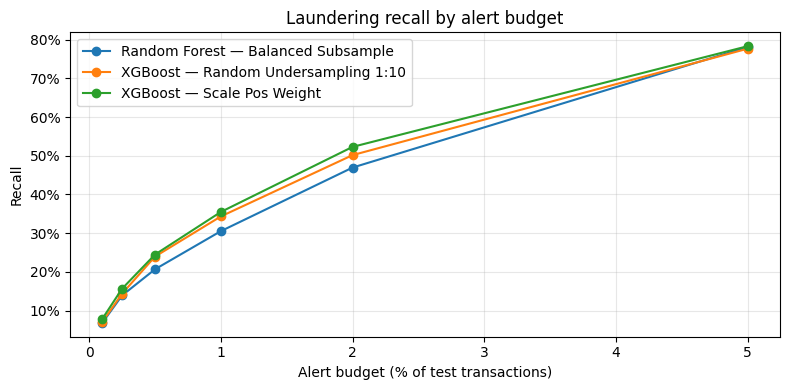

In [ ]:
plt.figure(figsize=(8, 4))

for model_name, model_data in alert_budget_results.groupby("model"):
    model_data = model_data.sort_values("alert_budget_pct")

    plt.plot(
        model_data["alert_budget_pct"],
        model_data["recall"],
        marker="o",
        label=model_name,
    )

plt.title("Laundering recall by alert budget")
plt.xlabel("Alert budget (% of test transactions)")
plt.ylabel("Recall")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation — Recall by alert budget

Laundering recall increases consistently as the alert budget expands, confirming that reviewing a larger fraction of transactions allows the models to recover more illicit cases.

The **XGBoost model with `scale_pos_weight`** achieves the highest recall across all evaluated alert budgets. Its advantage is most visible under restricted investigation capacity. With only **0.10% of the test transactions** selected for review, the model detects approximately **8% of all laundering cases**, compared with approximately 7% for the other candidates.

At an alert budget of **0.50%**, the weighted XGBoost detects approximately **24%** of the laundering transactions. Recall rises to approximately **36% at 1%**, **52% at 2%**, and **78% at 5%**.

The Random Forest consistently produces the lowest recall, particularly between the 0.50% and 2.00% budgets. The undersampled XGBoost performs closer to the weighted XGBoost, but remains slightly below it throughout the evaluated range.

The models converge as the alert budget approaches 5%, indicating that progressively larger alert volumes reduce the importance of the highest-risk ranking positions. However, this convergence comes at a substantial operational cost: reviewing 5% of the test set corresponds to more than 76,000 alerts.

Overall, the weighted XGBoost provides the strongest laundering coverage under equal investigation budgets. The result confirms that its higher Average Precision translates into better placement of illicit transactions near the top of the risk ranking.


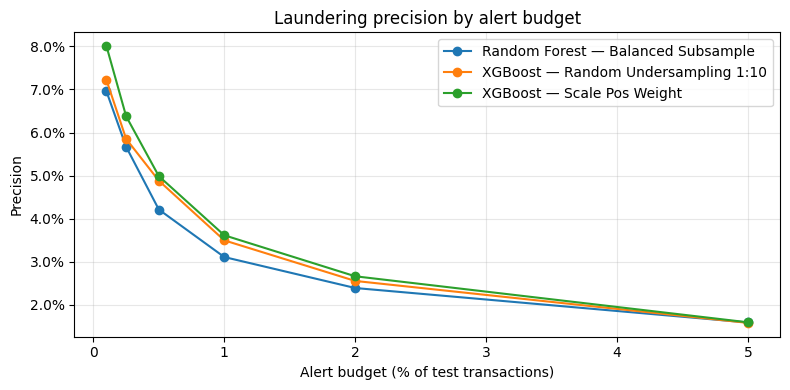

In [ ]:
plt.figure(figsize=(8, 4))

for model_name, model_data in alert_budget_results.groupby("model"):
    model_data = model_data.sort_values("alert_budget_pct")

    plt.plot(
        model_data["alert_budget_pct"],
        model_data["precision"],
        marker="o",
        label=model_name,
    )

plt.title("Laundering precision by alert budget")
plt.xlabel("Alert budget (% of test transactions)")
plt.ylabel("Precision")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation — Precision by alert budget

Precision decreases as the alert budget increases. This pattern is expected because the smallest budgets contain only the highest-ranked transactions, while larger budgets progressively include lower-risk observations that are predominantly legitimate.

The **XGBoost model with `scale_pos_weight`** provides the highest precision across the evaluated budgets. At the most restrictive **0.10% alert budget**, approximately **8% of its alerts** correspond to actual laundering transactions. This is substantially higher than the global laundering prevalence of approximately 0.1019%, showing that the model concentrates illicit cases effectively at the top of its ranking.

At a budget of **0.50%**, weighted XGBoost precision remains close to **5%**, equivalent to approximately one laundering case for every 20 alerts reviewed. Precision decreases to approximately **3.6% at a 1% budget**, **2.7% at 2%**, and **1.6% at 5%**.

The undersampled XGBoost generally performs close to the weighted model, while the Random Forest produces lower precision, especially between the 0.50% and 2.00% budgets. The difference between the models becomes smaller as the budget reaches 5%, because all classifiers begin including a larger proportion of lower-ranked legitimate transactions.

The graph illustrates the central operational trade-off of the project. Small budgets produce higher-quality alerts but detect fewer laundering transactions. Larger budgets improve recall, but require analysts to review a much greater number of false positives.

Although precision values appear low in absolute terms, they must be interpreted relative to the base rate. For example, a precision near 5% is approximately 49 times greater than the prevalence of laundering in the complete dataset.


### 8.8 Precision–recall curves

The alert-budget analysis evaluates a limited set of operational scenarios. Precision–recall curves complement this analysis by showing model performance across all available score thresholds.

The curve illustrates the trade-off between:

- detecting a larger proportion of laundering transactions;
- maintaining a sufficiently high proportion of true illicit cases among the generated alerts.

Average Precision summarises the overall quality of each model's ranking. However, the final operating point must still be selected according to investigation capacity and minimum acceptable alert precision.

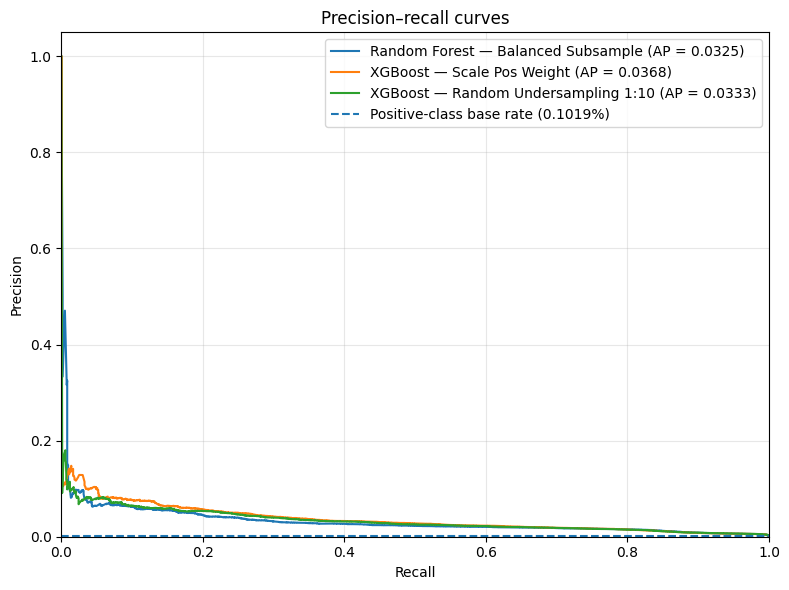

In [ ]:
plt.figure(figsize=(8, 6))

for model_name, model_scores in candidate_score_sets.items():
    precision_values, recall_values, _ = precision_recall_curve(
        y_test,
        model_scores,
    )

    average_precision = average_precision_score(
        y_test,
        model_scores,
    )

    plt.plot(
        recall_values,
        precision_values,
        label=(
            f"{model_name} "
            f"(AP = {average_precision:.4f})"
        ),
    )

plt.axhline(
    y=float(y_test.mean()),
    linestyle="--",
    label=f"Positive-class base rate ({y_test.mean():.4%})",
)

plt.title("Precision–recall curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation — Precision–recall curves

The precision–recall curves confirm that all three tree-based models rank laundering transactions substantially better than random selection. Their curves remain well above the positive-class base-rate reference of approximately **0.1019%** across most of the recall range.

The **XGBoost model with `scale_pos_weight`** achieves the highest overall Average Precision:

* weighted XGBoost: **0.036833**;
* undersampled XGBoost: **0.033282**;
* Random Forest: **0.032510**.

This makes the weighted XGBoost the strongest global ranking model. Its higher Average Precision is consistent with the alert-budget analysis, in which it generally achieved the highest recall and precision for an equivalent number of alerts.

The sharp precision fluctuations near zero recall are caused by the very small number of transactions included at the extreme top of the ranking. At that point, one additional true or false positive can produce a large change in precision. These isolated spikes should therefore not be treated as stable operating regions.

As recall increases, precision falls rapidly. This reflects the extreme class imbalance: once the most suspicious transactions have been included, each additional expansion of the alert set introduces a large number of legitimate transactions.

The curves also show that no model is uniformly superior at every individual threshold. The undersampled XGBoost is competitive in parts of the low-to-moderate recall region, while the weighted XGBoost provides the best performance when results are summarised across the full threshold range.

For this reason, Average Precision identifies the leading ranking model, but the final operating point must still be selected according to a specific minimum precision or alert-budget requirement.


### 8.9 Recall at fixed precision

In an operational AML setting, unlimited recall is not useful if almost every generated alert is a false positive.

The following analysis therefore identifies the maximum laundering recall achieved by each model while maintaining predefined minimum precision levels.

Four precision requirements are evaluated:

- **0.50%** — approximately one laundering case per 200 alerts;
- **1.00%** — approximately one case per 100 alerts;
- **2.00%** — approximately one case per 50 alerts;
- **5.00%** — approximately one case per 20 alerts.

For each target, the analysis selects the threshold that provides the highest recall while satisfying the required minimum precision.

These operating points are derived retrospectively from the held-out comparison set. In a production system, thresholds should be selected on validation data and evaluated once on a separate test period.

In [ ]:
def evaluate_fixed_precision_targets(
    model_name,
    y_true,
    y_score,
    precision_targets,
):
    """
    Find the maximum recall achieved at each minimum precision target.
    """

    y_true_array = np.asarray(y_true, dtype=np.int8)
    y_score_array = np.asarray(y_score, dtype=np.float32)

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            y_true_array,
            y_score_array,
        )
    )

    # The final precision-recall point has no corresponding threshold.
    threshold_precision = precision_values[:-1]
    threshold_recall = recall_values[:-1]

    total_positives = int(y_true_array.sum())
    total_negatives = int((y_true_array == 0).sum())

    results = []

    for precision_target in precision_targets:
        valid_indices = np.flatnonzero(
            threshold_precision >= precision_target
        )

        if len(valid_indices) == 0:
            results.append(
                {
                    "model": model_name,
                    "precision_target": precision_target,
                    "threshold": np.nan,
                    "precision": np.nan,
                    "recall": np.nan,
                    "alerts": 0,
                    "alert_rate_pct": 0.0,
                    "true_positives": 0,
                    "false_positives": 0,
                    "false_negatives": total_positives,
                    "true_negatives": total_negatives,
                    "alerts_per_true_positive": np.nan,
                }
            )
            continue

        best_index = valid_indices[
            np.argmax(threshold_recall[valid_indices])
        ]

        selected_threshold = float(thresholds[best_index])

        predictions = (
            y_score_array >= selected_threshold
        ).astype(np.int8)

        tn, fp, fn, tp = confusion_matrix(
            y_true_array,
            predictions,
            labels=[0, 1],
        ).ravel()

        alert_count = int(predictions.sum())

        achieved_precision = (
            tp / alert_count
            if alert_count > 0
            else 0.0
        )

        achieved_recall = (
            tp / total_positives
            if total_positives > 0
            else 0.0
        )

        alerts_per_true_positive = (
            alert_count / tp
            if tp > 0
            else np.inf
        )

        results.append(
            {
                "model": model_name,
                "precision_target": precision_target,
                "threshold": selected_threshold,
                "precision": achieved_precision,
                "recall": achieved_recall,
                "alerts": alert_count,
                "alert_rate_pct": (
                    alert_count / len(y_true_array) * 100
                ),
                "true_positives": int(tp),
                "false_positives": int(fp),
                "false_negatives": int(fn),
                "true_negatives": int(tn),
                "alerts_per_true_positive": (
                    alerts_per_true_positive
                ),
            }
        )

    return pd.DataFrame(results)

### 8.10 Fixed-precision operating points

The candidate models are now evaluated under the same minimum precision requirements.

Unlike the equal-budget comparison, the number of alerts may differ between models. The objective is to identify which classifier retains the greatest laundering coverage while satisfying each alert-quality requirement.

In [ ]:
precision_targets = [
    0.005,  # 0.50%
    0.010,  # 1.00%
    0.020,  # 2.00%
    0.050,  # 5.00%
]

fixed_precision_results = pd.concat(
    [
        evaluate_fixed_precision_targets(
            model_name=model_name,
            y_true=y_test,
            y_score=model_scores,
            precision_targets=precision_targets,
        )
        for model_name, model_scores
        in candidate_score_sets.items()
    ],
    ignore_index=True,
)

fixed_precision_display = (
    fixed_precision_results[
        [
            "precision_target",
            "model",
            "threshold",
            "precision",
            "recall",
            "alerts",
            "alert_rate_pct",
            "true_positives",
            "false_positives",
            "false_negatives",
            "alerts_per_true_positive",
        ]
    ]
    .sort_values(
        by=[
            "precision_target",
            "recall",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

print("Model performance at fixed precision targets:")

with pd.option_context(
    "display.float_format",
    "{:,.6f}".format,
):
    display(fixed_precision_display)

Model performance at fixed precision targets:


,precision_target,model,threshold,precision,recall,alerts,alert_rate_pct,true_positives,false_positives,false_negatives,alerts_per_true_positive
0,0.005000,Random Forest — Balanced Subsample,0.026577,0.005002,0.994205,308677,20.260990,1544,307133,9,199.920337
1,0.005000,XGBoost — Scale Pos Weight,0.034382,0.005001,0.990985,307734,20.199094,1539,306195,14,199.957115
2,0.005000,XGBoost — Random Undersampling 1:10,0.008554,0.005001,0.989697,307335,20.172904,1537,305798,16,199.957710
3,0.010000,Random Forest — Balanced Subsample,0.313334,0.010001,0.875724,135992,8.926265,1360,134632,193,99.994118
4,0.010000,XGBoost — Random Undersampling 1:10,0.157149,0.010000,0.869285,134999,8.861086,1350,133649,203,99.999259
5,0.010000,XGBoost — Scale Pos Weight,0.594836,0.010001,0.867997,134793,8.847565,1348,133445,205,99.994807
6,0.020000,XGBoost — Scale Pos Weight,0.892163,0.020002,0.670316,52044,3.416072,1041,51003,512,49.994236
7,0.020000,XGBoost — Random Undersampling 1:10,0.464850,0.020001,0.651642,50598,3.321160,1012,49586,541,49.998024
8,0.020000,Random Forest — Balanced Subsample,0.796275,0.020001,0.610431,47397,3.111052,948,46449,605,49.996835
9,0.050000,XGBoost — Scale Pos Weight,0.967236,0.050033,0.241468,7495,0.491958,375,7120,1178,19.986667


### 8.11 Best model at each minimum precision requirement

For each minimum precision requirement, the preferred model is identified by the highest achieved recall.

This represents the classifier that detects the greatest number of laundering transactions while respecting the specified minimum alert quality.

In [ ]:
valid_fixed_precision_results = (
    fixed_precision_results.dropna(
        subset=[
            "precision",
            "recall",
            "threshold",
        ]
    )
)

best_model_per_precision = (
    valid_fixed_precision_results.loc[
        valid_fixed_precision_results
        .groupby("precision_target")["recall"]
        .idxmax()
    ]
    [
        [
            "precision_target",
            "model",
            "threshold",
            "precision",
            "recall",
            "alerts",
            "alert_rate_pct",
            "true_positives",
            "false_positives",
            "false_negatives",
            "alerts_per_true_positive",
        ]
    ]
    .sort_values("precision_target")
    .reset_index(drop=True)
)

print("Best model at each minimum precision target:")

with pd.option_context(
    "display.float_format",
    "{:,.6f}".format,
):
    display(best_model_per_precision)

Best model at each minimum precision target:


,precision_target,model,threshold,precision,recall,alerts,alert_rate_pct,true_positives,false_positives,false_negatives,alerts_per_true_positive
0,0.005000,Random Forest — Balanced Subsample,0.026577,0.005002,0.994205,308677,20.260990,1544,307133,9,199.920337
1,0.010000,Random Forest — Balanced Subsample,0.313334,0.010001,0.875724,135992,8.926265,1360,134632,193,99.994118
2,0.020000,XGBoost — Scale Pos Weight,0.892163,0.020002,0.670316,52044,3.416072,1041,51003,512,49.994236
3,0.050000,XGBoost — Scale Pos Weight,0.967236,0.050033,0.241468,7495,0.491958,375,7120,1178,19.986667


#### Interpretation — Performance at fixed precision targets

The fixed-precision analysis shows how much laundering coverage can be retained when progressively stricter alert-quality requirements are imposed.

At a minimum precision of **0.50%**, the Random Forest achieves the highest recall, detecting **1,544 of the 1,553 laundering transactions**, equivalent to **99.42% recall**. However, this requires **308,677 alerts**, or **20.26% of the entire test set**. Although almost every illicit case is detected, approximately 200 alerts must be reviewed for each true laundering transaction.

At a minimum precision of **1.00%**, the Random Forest remains the best-performing model. It detects **1,360 laundering transactions**, reaching **87.57% recall**, but still generates **135,992 alerts**, corresponding to 8.93% of the test set.

When the minimum precision requirement increases to **2.00%**, the weighted XGBoost becomes the preferred model. It detects **1,041 laundering transactions**, achieving **67.03% recall** with **52,044 alerts**. This operating point requires approximately 50 alert reviews per detected illicit transaction.

At a minimum precision of **5.00%**, weighted XGBoost remains the strongest candidate. It produces only **7,495 alerts**, representing **0.49% of the test set**, but recall decreases to **24.15%**, with 375 laundering transactions detected and 1,178 remaining undetected.

These results demonstrate that no operating point simultaneously provides near-complete laundering coverage and high alert precision. The Random Forest performs better when very low precision is accepted in exchange for maximum recall, whereas weighted XGBoost becomes superior when alert quality requirements are more restrictive.

For the AMLGuard use case, the 0.50% and 1.00% precision scenarios would create an excessive review workload. The **5.00% precision operating point of the weighted XGBoost** provides the most manageable alert volume, but its low recall creates substantial regulatory exposure. The **2.00% precision operating point** offers a more balanced analytical compromise, detecting approximately two-thirds of laundering transactions while restricting alerts to 3.42% of the test set.

The final operating point should not be presented as universally optimal. It represents a business decision that depends on analyst capacity, investigation costs, and the institution's tolerance for undetected laundering risk.

### 8.12 Selected operating point — required rubric metrics

The project rubric requires the evaluation section to present at least accuracy, a confusion matrix, and a classification report.

These metrics were previously reported for each model at the default threshold of 0.50. They are now consolidated for the selected candidate and a **demonstration operating point** based on a minimum precision target of 2.00%.

The selected candidate is the XGBoost classifier trained with `scale_pos_weight`. This point offers a more balanced analytical trade-off between laundering coverage and alert workload than the other evaluated scenarios.

Because both the model comparison and threshold selection used the same held-out set, the figures below are descriptive and may be optimistic. A production workflow should select the threshold on validation data and report final performance once on a later, untouched test period.

Average Precision and alert-budget metrics remain the primary comparison tools because accuracy alone is misleading under extreme class imbalance.


In [ ]:
FINAL_MODEL_NAME = "XGBoost — Scale Pos Weight"
FINAL_PRECISION_TARGET = 0.02

final_operating_point = fixed_precision_results.loc[
    (
        fixed_precision_results["model"]
        == FINAL_MODEL_NAME
    )
    & np.isclose(
        fixed_precision_results["precision_target"],
        FINAL_PRECISION_TARGET,
    )
].iloc[0]

final_threshold = float(
    final_operating_point["threshold"]
)

final_scores = np.asarray(
    xgboost_scores,
    dtype=np.float32,
)

final_predictions = (
    final_scores >= final_threshold
).astype(np.int8)

final_accuracy = accuracy_score(
    y_test,
    final_predictions,
)

final_average_precision = average_precision_score(
    y_test,
    final_scores,
)

final_confusion_matrix = confusion_matrix(
    y_test,
    final_predictions,
    labels=[0, 1],
)

tn, fp, fn, tp = final_confusion_matrix.ravel()

final_alert_count = int(
    final_predictions.sum()
)

final_alert_rate = (
    final_alert_count / len(y_test) * 100
)

print("=" * 70)
print("Final model evaluation")
print("=" * 70)
print(f"Model:              {FINAL_MODEL_NAME}")
print(f"Decision threshold: {final_threshold:.6f}")
print(f"Accuracy:           {final_accuracy:.6f}")
print(
    f"Average Precision:  "
    f"{final_average_precision:.6f}"
)
print(
    f"Alerts generated:   "
    f"{final_alert_count:,} "
    f"({final_alert_rate:.4f}% of test transactions)"
)
print(f"True positives:      {tp:,}")
print(f"False positives:     {fp:,}")
print(f"False negatives:     {fn:,}")
print(f"True negatives:      {tn:,}")

Final model evaluation
Model:              XGBoost — Scale Pos Weight
Decision threshold: 0.892163
Accuracy:           0.966187
Average Precision:  0.036833
Alerts generated:   52,044 (3.4161% of test transactions)
True positives:      1,041
False positives:     51,003
False negatives:     512
True negatives:      1,470,948


In [ ]:
final_confusion_table = pd.DataFrame(
    final_confusion_matrix,
    index=[
        "Actual legitimate",
        "Actual laundering",
    ],
    columns=[
        "Predicted legitimate",
        "Predicted laundering",
    ],
)

print("Final model confusion matrix:")
display(final_confusion_table)

Final model confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1470948,51003
Actual laundering,512,1041


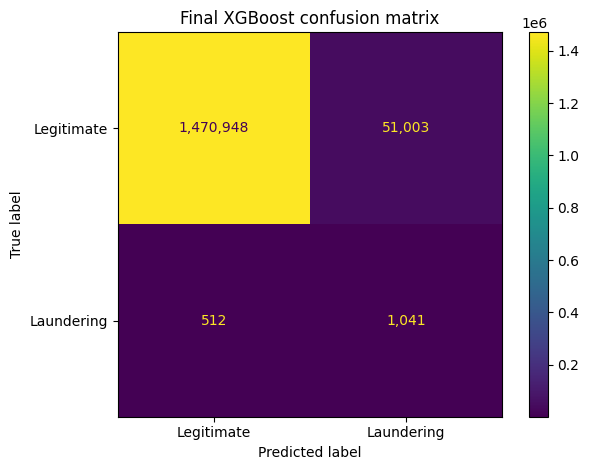

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=[
        "Legitimate",
        "Laundering",
    ],
).plot(
    values_format=",d",
)

plt.title(
    "Final XGBoost confusion matrix"
)
plt.tight_layout()
plt.show()

In [ ]:
print("Final model classification report:")

print(
    classification_report(
        y_test,
        final_predictions,
        labels=[0, 1],
        target_names=[
            "Legitimate",
            "Laundering",
        ],
        digits=6,
        zero_division=0,
    )
)

Final model classification report:
              precision    recall  f1-score   support

  Legitimate   0.999652  0.966488  0.982791   1521951
  Laundering   0.020002  0.670316  0.038845      1553

    accuracy                       0.966187   1523504
   macro avg   0.509827  0.818402  0.510818   1523504
weighted avg   0.998653  0.966187  0.981828   1523504



#### Interpretation — Final rubric evaluation

At the selected demonstration operating point, the weighted XGBoost uses a decision threshold of approximately **0.8922**.

The model achieves an accuracy of approximately **96.62%**. However, this value remains a secondary metric because legitimate transactions represent almost the entire dataset. Accuracy must therefore be interpreted together with the confusion matrix and the minority-class metrics.

The confusion matrix shows:

* **1,470,948 true negatives:** legitimate transactions correctly left without an alert;
* **51,003 false positives:** legitimate transactions incorrectly flagged for investigation;
* **512 false negatives:** laundering transactions that remained undetected;
* **1,041 true positives:** laundering transactions correctly detected.

The model generates **52,044 alerts**, corresponding to approximately **3.42% of the test transactions**.

For the laundering class, the classification report shows approximately:

* **2.00% precision:** one true laundering case for every 50 alerts reviewed;
* **67.03% recall:** about two-thirds of all laundering transactions are detected;
* **3.88% F1-score:** the harmonic balance between the low precision and the substantially higher recall.

The relatively high overall accuracy does not mean that the classification task is solved. The operationally relevant result is that the model detects 1,041 laundering transactions while generating 51,003 false-positive investigations and missing 512 illicit cases.

This operating point represents an analytical compromise rather than a universally optimal production threshold. A real financial institution would need to choose the threshold according to analyst capacity, investigation costs, and tolerance for undetected regulatory risk.


Because the same held-out set was used to compare models and select this operating point, the metrics should not be interpreted as an unbiased production estimate. This limitation is carried into the critical conclusion.

### 8.13 Section 8 rubric coverage

| Required evaluation item | Notebook coverage |
|---|---|
| Accuracy | Reported for the selected XGBoost demonstration operating point |
| Confusion matrix | Presented as a table and graphical matrix |
| Classification report | Presented for legitimate and laundering classes |
| Additional analysis | Average Precision, precision–recall curves, equal alert budgets, fixed-precision operating points and threshold analysis |

All minimum evaluation requirements are therefore explicitly covered. The additional metrics are included because the extreme class imbalance makes accuracy insufficient as the primary measure of model usefulness.

### 8.14 Section summary and selected candidate

The weighted XGBoost is selected as the leading model because it achieved the highest Average Precision (**0.036833**) and the strongest recall under equal alert budgets.

For the academic demonstration, a threshold of approximately **0.8922** is retained because it reaches the predefined minimum precision target of **2.00%**. At this point, the model detects **1,041 of 1,553 laundering transactions** (**67.03% recall**) and generates **52,044 alerts** (**3.42% of the test set**).

This is not presented as a universally optimal or production-ready threshold. The model was evaluated on synthetic data from an 18-day window, the operating point was selected retrospectively on the same held-out set, and the alert volume would still be substantial for many institutions.

The next step is model explainability with SHAP, followed by the critical conclusion required in Section 9.


### 8.15 Model explainability with SHAP

The weighted XGBoost has been selected as the leading AMLGuard model based on its Average Precision and its performance under equal alert budgets.

SHAP is used to examine how the model combines the transformed features when producing laundering-risk scores. The analysis has two objectives:

1. identify the features with the greatest global influence on the model output;
2. explain one correctly detected laundering alert and one legitimate transaction incorrectly flagged for investigation.

SHAP values describe associations learned by the model. They do not establish causal relationships, and patterns learned from this synthetic dataset may not transfer directly to real banking data.


#### 8.15.1 Sparse-input validation and SHAP sample preparation

The fitted preprocessing pipeline returns a sparse matrix. This representation must be preserved when scoring the XGBoost model and when calculating SHAP values.

For XGBoost, converting the fitted sparse matrix to a dense array is not a neutral formatting operation. Entries absent from a sparse matrix follow the model's learned missing-value paths, while dense zeros are treated as explicit numerical values. Densifying the matrix before prediction can therefore change the score and produce an explanation for a different model input.

The corrected workflow keeps the transformed matrix sparse for both prediction and SHAP computation. A dense copy is created only as display data for the plots. The code also verifies that:

- the complete pipeline and the extracted classifier return the same positive-class score;
- applying the logistic function to the raw margin reproduces that score;
- the SHAP base value plus all feature contributions reconstructs the raw margin.

A reproducible sample of 5,000 test transactions is used for global explainability.


In [ ]:
import shap
from scipy import sparse
from scipy.special import expit
from IPython.display import Markdown


final_preprocessor = xgboost_weighted.named_steps[
    "preprocessor"
]
final_classifier = xgboost_weighted.named_steps[
    "classifier"
]

positive_class_index = int(
    np.flatnonzero(
        final_classifier.classes_ == 1
    )[0]
)

transformed_feature_names = (
    final_preprocessor.get_feature_names_out()
)
clean_feature_names = [
    feature_name.split("__", 1)[-1]
    for feature_name in transformed_feature_names
]

SHAP_SAMPLE_SIZE = 5_000

shap_sample = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=RANDOM_STATE,
)

transformed_shap_sparse = (
    final_preprocessor.transform(shap_sample)
)

if not sparse.issparse(
    transformed_shap_sparse
):
    transformed_shap_sparse = sparse.csr_matrix(
        transformed_shap_sparse
    )
else:
    transformed_shap_sparse = (
        transformed_shap_sparse.tocsr()
    )

# Dense values are used only for labels and plot display.
transformed_shap_display = (
    transformed_shap_sparse.toarray().astype(
        np.float32,
        copy=False,
    )
)

pipeline_sample_scores = (
    xgboost_weighted.predict_proba(
        shap_sample
    )[:, positive_class_index]
)

classifier_sample_scores = (
    final_classifier.predict_proba(
        transformed_shap_sparse
    )[:, positive_class_index]
)

sample_raw_margins = np.asarray(
    final_classifier.predict(
        transformed_shap_sparse,
        output_margin=True,
    ),
    dtype=np.float64,
).reshape(-1)

sample_scores_from_margin = expit(
    sample_raw_margins
)

pipeline_classifier_error = float(
    np.max(
        np.abs(
            pipeline_sample_scores
            - classifier_sample_scores
        )
    )
)

margin_probability_error = float(
    np.max(
        np.abs(
            classifier_sample_scores
            - sample_scores_from_margin
        )
    )
)

if pipeline_classifier_error > 1e-6:
    raise RuntimeError(
        "The extracted classifier does not reproduce "
        "the pipeline scores. Maximum difference: "
        f"{pipeline_classifier_error:.10f}"
    )

if margin_probability_error > 1e-6:
    raise RuntimeError(
        "The raw XGBoost margins do not reproduce "
        "the positive-class scores. Maximum difference: "
        f"{margin_probability_error:.10f}"
    )

print("=" * 72)
print("Sparse-input validation")
print("=" * 72)
print(f"SHAP sample size:                 {len(shap_sample):,}")
print(
    "Transformed feature count:       "
    f"{transformed_shap_sparse.shape[1]}"
)
print(
    "Sparse transformed matrix:       "
    f"{sparse.issparse(transformed_shap_sparse)}"
)
print(
    "Pipeline/classifier max error:   "
    f"{pipeline_classifier_error:.10f}"
)
print(
    "Margin/probability max error:    "
    f"{margin_probability_error:.10f}"
)
print(
    "Test-set laundering base rate:   "
    f"{y_test.mean():.4%}"
)


Sparse-input validation
SHAP sample size:                 5,000
Transformed feature count:       11
Sparse transformed matrix:       True
Pipeline/classifier max error:   0.0000000000
Margin/probability max error:    0.0000000757
Test-set laundering base rate:   0.1019%


In [ ]:
def _base_values_for_output(
    base_values,
    n_rows,
    output_index=None,
):
    """Return one SHAP base value for each explained row."""

    base_array = np.asarray(
        base_values,
        dtype=np.float64,
    )

    if base_array.ndim == 0:
        return np.full(
            n_rows,
            float(base_array),
        )

    if base_array.ndim == 1:
        if base_array.size == n_rows:
            return base_array

        selected_index = (
            0
            if output_index is None
            else output_index
        )
        return np.full(
            n_rows,
            float(base_array[selected_index]),
        )

    if base_array.ndim == 2:
        selected_index = (
            0
            if output_index is None
            else output_index
        )
        return base_array[
            :,
            selected_index,
        ]

    raise ValueError(
        "Unsupported SHAP base-value shape: "
        f"{base_array.shape}"
    )


def build_validated_shap_explanation(
    raw_explanation,
    model_margins,
    display_data,
    feature_names,
    tolerance=1e-4,
):
    """
    Select the SHAP output that reconstructs the raw XGBoost margin.

    The function supports the two-dimensional output normally returned
    for binary XGBoost models and the optional three-dimensional output
    returned by some SHAP/model combinations.
    """

    shap_values = np.asarray(
        raw_explanation.values,
        dtype=np.float64,
    )
    model_margins = np.asarray(
        model_margins,
        dtype=np.float64,
    ).reshape(-1)
    display_data = np.asarray(
        display_data,
        dtype=np.float32,
    )

    n_rows = len(model_margins)
    candidates = []

    if shap_values.ndim == 2:
        candidates.append(
            (None, shap_values)
        )
    elif shap_values.ndim == 3:
        for output_index in range(
            shap_values.shape[2]
        ):
            candidates.append(
                (
                    output_index,
                    shap_values[
                        :,
                        :,
                        output_index,
                    ],
                )
            )
    else:
        raise ValueError(
            "Unsupported SHAP value shape: "
            f"{shap_values.shape}"
        )

    evaluated_candidates = []

    for output_index, candidate_values in candidates:
        candidate_base_values = (
            _base_values_for_output(
                raw_explanation.base_values,
                n_rows=n_rows,
                output_index=output_index,
            )
        )

        reconstructed_margins = (
            candidate_base_values
            + candidate_values.sum(axis=1)
        )

        absolute_errors = np.abs(
            reconstructed_margins
            - model_margins
        )

        evaluated_candidates.append(
            {
                "output_index": output_index,
                "values": candidate_values,
                "base_values": candidate_base_values,
                "mean_error": float(
                    absolute_errors.mean()
                ),
                "maximum_error": float(
                    absolute_errors.max()
                ),
            }
        )

    best_candidate = min(
        evaluated_candidates,
        key=lambda candidate: (
            candidate["mean_error"]
        ),
    )

    if best_candidate["maximum_error"] > tolerance:
        raise RuntimeError(
            "SHAP values do not reconstruct the "
            "XGBoost raw margins. Maximum error: "
            f"{best_candidate['maximum_error']:.10f}"
        )

    explanation = shap.Explanation(
        values=best_candidate["values"],
        base_values=best_candidate[
            "base_values"
        ],
        data=display_data,
        feature_names=feature_names,
    )

    return explanation, best_candidate


shap_explainer = shap.TreeExplainer(
    final_classifier.get_booster(),
    model_output="raw",
)

raw_global_shap = shap_explainer(
    transformed_shap_sparse,
    check_additivity=False,
)

global_shap_explanation, global_shap_validation = (
    build_validated_shap_explanation(
        raw_explanation=raw_global_shap,
        model_margins=sample_raw_margins,
        display_data=transformed_shap_display,
        feature_names=clean_feature_names,
    )
)

print("=" * 72)
print("Validated global SHAP explanation")
print("=" * 72)
print(
    "Selected output index:           "
    f"{global_shap_validation['output_index']}"
)
print(
    "Mean reconstruction error:       "
    f"{global_shap_validation['mean_error']:.10f}"
)
print(
    "Maximum reconstruction error:    "
    f"{global_shap_validation['maximum_error']:.10f}"
)


Validated global SHAP explanation
Selected output index:           None
Mean reconstruction error:       0.0000013576
Maximum reconstruction error:    0.0000068359


#### 8.15.2 Global feature importance

The global SHAP bar plot ranks the transformed features by their mean absolute SHAP value. A larger value means that the feature causes larger changes in the model's raw output across the explanation sample.

The magnitude does not show whether the feature increases or decreases risk, and it must not be interpreted as causal importance.


Global SHAP importance:


,feature,mean_absolute_shap
0,Payment Format_ACH,2.191655
1,sender_previous_tx_count,2.155367
2,Amount Paid,0.898911
3,Payment Format_Credit Card,0.575245
4,same_account,0.555615
5,Payment Format_Cheque,0.445264
6,Payment Format_Cash,0.168747
7,is_business_hours,0.164391
8,Payment Format_Reinvestment,0.147391
9,Payment Format_Wire,0.097327


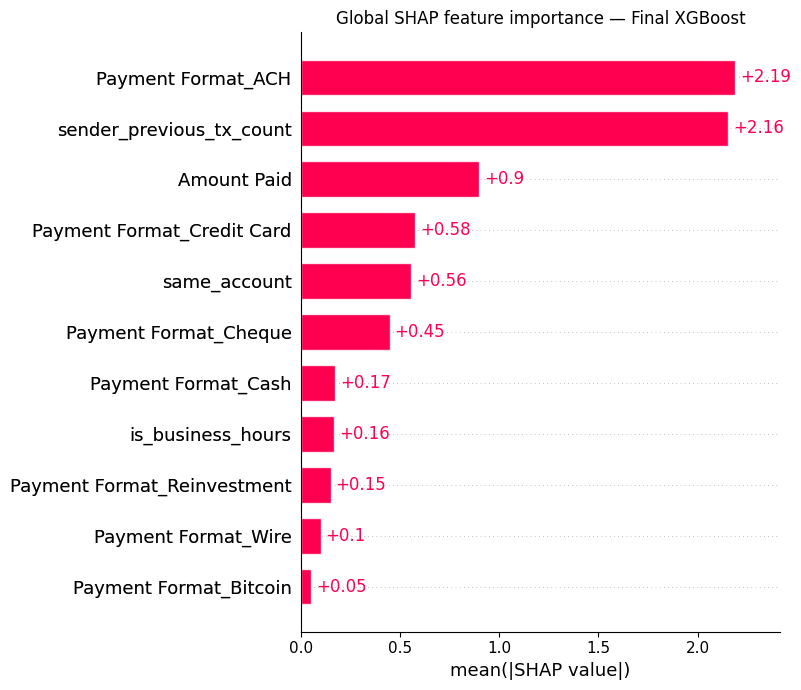

In [ ]:
global_shap_importance = (
    pd.DataFrame(
        {
            "feature": clean_feature_names,
            "mean_absolute_shap": np.abs(
                global_shap_explanation.values
            ).mean(axis=0),
        }
    )
    .sort_values(
        "mean_absolute_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Global SHAP importance:")
with pd.option_context(
    "display.float_format",
    "{:.6f}".format,
):
    display(global_shap_importance)

shap.plots.bar(
    global_shap_explanation,
    max_display=15,
    show=False,
)

plt.title(
    "Global SHAP feature importance — Final XGBoost"
)
plt.tight_layout()
plt.show()


In [ ]:
top_global_features = (
    global_shap_importance.head(5)
)

top_feature_lines = "\n".join(
    [
        (
            f"- `{row.feature}`: "
            f"{row.mean_absolute_shap:.4f}"
        )
        for row in top_global_features.itertuples()
    ]
)

display(
    Markdown(
        f"""
#### Interpretation — Global SHAP feature importance

The validated sparse-input explanation identifies the following five
features as the most influential by mean absolute SHAP value:

{top_feature_lines}

These values quantify average contribution magnitude on the raw XGBoost
margin. They do not indicate direction and do not imply causality. The
ranking should also be interpreted in light of the synthetic origin of
the dataset: a highly influential feature may capture a rule of the data
generator rather than a stable pattern in real banking activity.
"""
    )
)



#### Interpretation — Global SHAP feature importance

The validated sparse-input explanation identifies the following five
features as the most influential by mean absolute SHAP value:

- `Payment Format_ACH`: 2.1917
- `sender_previous_tx_count`: 2.1554
- `Amount Paid`: 0.8989
- `Payment Format_Credit Card`: 0.5752
- `same_account`: 0.5556

These values quantify average contribution magnitude on the raw XGBoost
margin. They do not indicate direction and do not imply causality. The
ranking should also be interpreted in light of the synthetic origin of
the dataset: a highly influential feature may capture a rule of the data
generator rather than a stable pattern in real banking activity.


#### 8.15.3 SHAP value distribution

The beeswarm plot adds direction and distribution to the global ranking.

Each point represents one transaction. Positive SHAP values increase the raw laundering-risk margin, while negative values decrease it. Colour represents the transformed feature value. For one-hot and binary features, a value of one indicates that the corresponding category or condition is present.

The SHAP scale is the model's raw margin, approximately log-odds, rather than a direct change in probability.


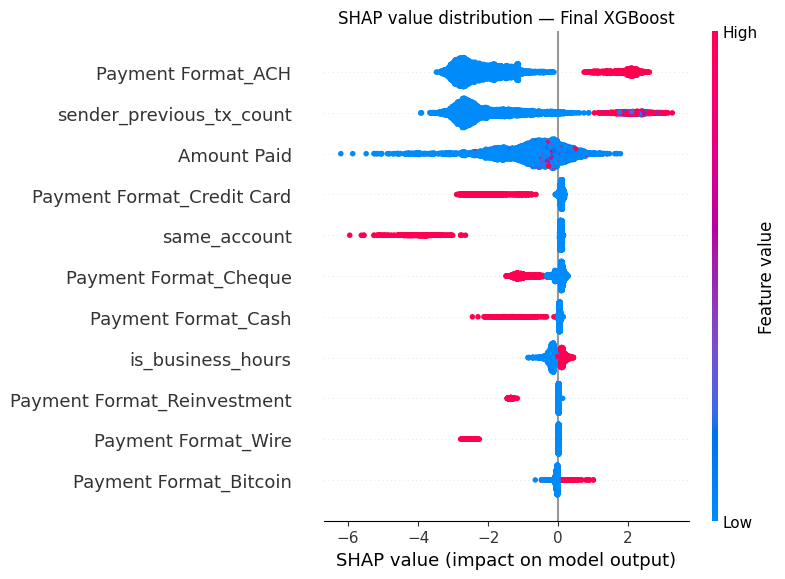

In [ ]:
shap.plots.beeswarm(
    global_shap_explanation,
    max_display=15,
    show=False,
)

plt.title(
    "SHAP value distribution — Final XGBoost"
)
plt.tight_layout()
plt.show()


In [ ]:
global_feature_values = pd.DataFrame(
    transformed_shap_display,
    columns=clean_feature_names,
)

global_feature_shap = pd.DataFrame(
    global_shap_explanation.values,
    columns=clean_feature_names,
)

direction_rows = []

for feature_name in clean_feature_names:
    feature_values = global_feature_values[
        feature_name
    ]
    feature_shap_values = global_feature_shap[
        feature_name
    ]

    unique_values = np.unique(
        feature_values.dropna()
    )

    if set(unique_values.tolist()).issubset(
        {0.0, 1.0}
    ):
        present_mask = feature_values == 1
        absent_mask = feature_values == 0

        present_mean = (
            float(
                feature_shap_values[
                    present_mask
                ].mean()
            )
            if present_mask.any()
            else np.nan
        )
        absent_mean = (
            float(
                feature_shap_values[
                    absent_mask
                ].mean()
            )
            if absent_mask.any()
            else np.nan
        )

        direction_rows.append(
            {
                "feature": feature_name,
                "feature_type": "binary / one-hot",
                "low_or_absent_mean_shap": (
                    absent_mean
                ),
                "high_or_present_mean_shap": (
                    present_mean
                ),
                "high_minus_low": (
                    present_mean - absent_mean
                ),
            }
        )
    else:
        lower_quartile = feature_values.quantile(
            0.25
        )
        upper_quartile = feature_values.quantile(
            0.75
        )

        low_mask = (
            feature_values <= lower_quartile
        )
        high_mask = (
            feature_values >= upper_quartile
        )

        low_mean = float(
            feature_shap_values[
                low_mask
            ].mean()
        )
        high_mean = float(
            feature_shap_values[
                high_mask
            ].mean()
        )

        direction_rows.append(
            {
                "feature": feature_name,
                "feature_type": "numeric",
                "low_or_absent_mean_shap": (
                    low_mean
                ),
                "high_or_present_mean_shap": (
                    high_mean
                ),
                "high_minus_low": (
                    high_mean - low_mean
                ),
            }
        )

global_direction_summary = (
    pd.DataFrame(direction_rows)
    .merge(
        global_shap_importance,
        on="feature",
        how="left",
    )
    .sort_values(
        "mean_absolute_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

global_direction_summary[
    "direction_for_high_or_present"
] = np.where(
    global_direction_summary[
        "high_minus_low"
    ] > 0,
    "Higher / present values increase the model output on average",
    np.where(
        global_direction_summary[
            "high_minus_low"
        ] < 0,
        "Higher / present values decrease the model output on average",
        "No average directional difference",
    ),
)

print("Directional SHAP summary:")
with pd.option_context(
    "display.float_format",
    "{:.6f}".format,
):
    display(
        global_direction_summary[
            [
                "feature",
                "feature_type",
                "mean_absolute_shap",
                "low_or_absent_mean_shap",
                "high_or_present_mean_shap",
                "high_minus_low",
                "direction_for_high_or_present",
            ]
        ]
    )

most_influential = (
    global_direction_summary.iloc[0]
)

direction_word = (
    "increases"
    if most_influential[
        "high_minus_low"
    ] > 0
    else "decreases"
)

display(
    Markdown(
        f"""
#### Interpretation — SHAP value distribution

The corrected beeswarm and directional summary explain the same sparse
inputs used by the fitted pipeline. The most influential feature is
`{most_influential['feature']}`. Its higher or present values
**{direction_word}** the model output on average in this sample.

The table should be used together with the beeswarm because averages can
hide non-linear effects and feature interactions. In particular, numerical
features may increase risk in one value range and decrease it in another.
The findings describe the classifier's learned associations, not causal
AML rules.
"""
    )
)


Directional SHAP summary:


,feature,feature_type,mean_absolute_shap,low_or_absent_mean_shap,high_or_present_mean_shap,high_minus_low,direction_for_high_or_present
0,Payment Format_ACH,binary / one-hot,2.191655,-2.235377,1.859762,4.095139,Higher / present values increase the model out...
1,sender_previous_tx_count,numeric,2.155367,-1.332292,-0.911067,0.421225,Higher / present values increase the model out...
2,Amount Paid,numeric,0.898911,-1.942822,-0.060059,1.882764,Higher / present values increase the model out...
3,Payment Format_Credit Card,binary / one-hot,0.575245,0.094936,-2.007584,-2.102521,Higher / present values decrease the model out...
4,same_account,binary / one-hot,0.555615,0.073237,-3.988639,-4.061877,Higher / present values decrease the model out...
5,Payment Format_Cheque,binary / one-hot,0.445264,0.051387,-0.989061,-1.040448,Higher / present values decrease the model out...
6,Payment Format_Cash,binary / one-hot,0.168747,0.046223,-1.290695,-1.336919,Higher / present values decrease the model out...
7,is_business_hours,binary / one-hot,0.164391,-0.186651,0.115471,0.302122,Higher / present values increase the model out...
8,Payment Format_Reinvestment,binary / one-hot,0.147391,0.012522,-1.358248,-1.370770,Higher / present values decrease the model out...
9,Payment Format_Wire,binary / one-hot,0.097327,0.015117,-2.552471,-2.567588,Higher / present values decrease the model out...



#### Interpretation — SHAP value distribution

The corrected beeswarm and directional summary explain the same sparse
inputs used by the fitted pipeline. The most influential feature is
`Payment Format_ACH`. Its higher or present values
**increases** the model output on average in this sample.

The table should be used together with the beeswarm because averages can
hide non-linear effects and feature interactions. In particular, numerical
features may increase risk in one value range and decrease it in another.
The findings describe the classifier's learned associations, not causal
AML rules.


#### 8.15.4 Technical correction and model-risk observation

An earlier version of this analysis converted the sparse transformed matrix to a dense array before scoring and explaining the model. That conversion changed XGBoost's treatment of absent entries and produced local SHAP margins that contradicted the pipeline probabilities.

The current implementation corrects the issue by preserving the CSR matrix for every model and SHAP call. Dense values are used only to display feature values in plots and tables. Numerical assertions stop execution if the pipeline score, classifier score, raw margin, and SHAP reconstruction are not consistent.

Even with technically valid explanations, influential features must be treated cautiously. Features such as `same_account` or a payment-format indicator may reflect synthetic-generator rules or proxy relationships. A production-oriented study should repeat the evaluation without potentially generator-specific features and validate the model on a later, independent time period.


### 8.16 Local alert explanations

Global SHAP analysis describes average model behaviour, but an AML analyst must also understand why a specific transaction was flagged.

Two cases are examined:

1. the highest-scoring true positive, representing a laundering transaction correctly detected by the selected operating point;
2. the highest-scoring false positive, representing a legitimate transaction incorrectly sent for investigation.

The selected scores are recomputed directly from the fitted pipeline to prevent stale notebook variables from being used.


In [ ]:
y_test_array = np.asarray(
    y_test,
    dtype=np.int8,
)

fresh_final_scores = (
    xgboost_weighted.predict_proba(
        X_test
    )[:, positive_class_index]
    .astype(np.float32)
)

stored_score_error = float(
    np.max(
        np.abs(
            fresh_final_scores
            - np.asarray(
                final_scores,
                dtype=np.float32,
            )
        )
    )
)

if stored_score_error > 1e-6:
    raise RuntimeError(
        "Stored final scores do not match the "
        "current fitted pipeline. Maximum difference: "
        f"{stored_score_error:.10f}"
    )

fresh_final_predictions = (
    fresh_final_scores >= final_threshold
).astype(np.int8)

true_positive_positions = np.flatnonzero(
    (y_test_array == 1)
    & (fresh_final_predictions == 1)
)

false_positive_positions = np.flatnonzero(
    (y_test_array == 0)
    & (fresh_final_predictions == 1)
)

if true_positive_positions.size == 0:
    raise RuntimeError(
        "No true-positive alerts were found."
    )

if false_positive_positions.size == 0:
    raise RuntimeError(
        "No false-positive alerts were found."
    )

highest_risk_true_positive = int(
    true_positive_positions[
        np.argmax(
            fresh_final_scores[
                true_positive_positions
            ]
        )
    ]
)

highest_risk_false_positive = int(
    false_positive_positions[
        np.argmax(
            fresh_final_scores[
                false_positive_positions
            ]
        )
    ]
)

selected_case_summary = pd.DataFrame(
    [
        {
            "case": "Highest-risk true positive",
            "test_position": highest_risk_true_positive,
            "original_index": X_test.index[
                highest_risk_true_positive
            ],
            "actual_label": int(
                y_test_array[
                    highest_risk_true_positive
                ]
            ),
            "predicted_label": int(
                fresh_final_predictions[
                    highest_risk_true_positive
                ]
            ),
            "risk_score": float(
                fresh_final_scores[
                    highest_risk_true_positive
                ]
            ),
        },
        {
            "case": "Highest-risk false positive",
            "test_position": highest_risk_false_positive,
            "original_index": X_test.index[
                highest_risk_false_positive
            ],
            "actual_label": int(
                y_test_array[
                    highest_risk_false_positive
                ]
            ),
            "predicted_label": int(
                fresh_final_predictions[
                    highest_risk_false_positive
                ]
            ),
            "risk_score": float(
                fresh_final_scores[
                    highest_risk_false_positive
                ]
            ),
        },
    ]
)

selected_case_summary[
    "decision_threshold"
] = final_threshold

selected_case_summary[
    "margin_above_threshold"
] = (
    selected_case_summary["risk_score"]
    - final_threshold
)

print(
    "Selected cases for validated local SHAP analysis:"
)
print(
    "Stored/current score maximum difference: "
    f"{stored_score_error:.10f}"
)

with pd.option_context(
    "display.float_format",
    "{:.6f}".format,
):
    display(selected_case_summary)


Selected cases for validated local SHAP analysis:
Stored/current score maximum difference: 0.0000000000


,case,test_position,original_index,actual_label,predicted_label,risk_score,decision_threshold,margin_above_threshold
0,Highest-risk true positive,123529,5078103,1,1,0.991125,0.892163,0.098961
1,Highest-risk false positive,50209,3467282,0,1,0.990650,0.892163,0.098486


#### 8.16.1 Validated local explanation method

For each selected transaction, the original row is transformed by the fitted preprocessor and remains sparse for both prediction and SHAP computation.

The local explanation is accepted only when all of the following values agree:

- score returned by the complete pipeline;
- score returned by the extracted classifier;
- logistic transformation of the raw XGBoost margin;
- SHAP base value plus the sum of all feature contributions.

The contribution table is ordered by absolute SHAP magnitude. Positive values increase the raw laundering-risk margin, while negative values decrease it.


In [ ]:
def _format_top_contributions(
    contribution_table,
    direction,
    top_n=3,
):
    selected = contribution_table.loc[
        contribution_table["shap_value"] * direction > 0
    ].head(top_n)

    if selected.empty:
        return "none"

    return ", ".join(
        [
            (
                f"`{row.feature}` "
                f"({row.shap_value:+.3f})"
            )
            for row in selected.itertuples()
        ]
    )


def explain_test_transaction(
    test_position,
    case_label,
):
    """Generate and validate one sparse-input local SHAP explanation."""

    transaction = X_test.iloc[
        [test_position]
    ].copy()

    transformed_transaction_sparse = (
        final_preprocessor.transform(
            transaction
        )
    )

    if not sparse.issparse(
        transformed_transaction_sparse
    ):
        transformed_transaction_sparse = (
            sparse.csr_matrix(
                transformed_transaction_sparse
            )
        )
    else:
        transformed_transaction_sparse = (
            transformed_transaction_sparse.tocsr()
        )

    transaction_display_data = (
        transformed_transaction_sparse
        .toarray()
        .astype(
            np.float32,
            copy=False,
        )
    )

    pipeline_probability = float(
        xgboost_weighted.predict_proba(
            transaction
        )[0, positive_class_index]
    )

    classifier_probability = float(
        final_classifier.predict_proba(
            transformed_transaction_sparse
        )[0, positive_class_index]
    )

    model_margin = float(
        np.asarray(
            final_classifier.predict(
                transformed_transaction_sparse,
                output_margin=True,
            ),
            dtype=np.float64,
        ).reshape(-1)[0]
    )

    probability_from_margin = float(
        expit(model_margin)
    )

    raw_local_shap = shap_explainer(
        transformed_transaction_sparse,
        check_additivity=False,
    )

    local_explanation_batch, local_validation = (
        build_validated_shap_explanation(
            raw_explanation=raw_local_shap,
            model_margins=np.array(
                [model_margin],
                dtype=np.float64,
            ),
            display_data=transaction_display_data,
            feature_names=clean_feature_names,
        )
    )

    local_explanation = (
        local_explanation_batch[0]
    )

    probability_errors = {
        "pipeline_vs_classifier": abs(
            pipeline_probability
            - classifier_probability
        ),
        "classifier_vs_margin": abs(
            classifier_probability
            - probability_from_margin
        ),
        "stored_vs_pipeline": abs(
            float(
                fresh_final_scores[
                    test_position
                ]
            )
            - pipeline_probability
        ),
    }

    maximum_probability_error = max(
        probability_errors.values()
    )

    if maximum_probability_error > 1e-6:
        raise RuntimeError(
            "Local probability validation failed. "
            f"Maximum difference: "
            f"{maximum_probability_error:.10f}"
        )

    local_values = np.asarray(
        local_explanation.values,
        dtype=np.float64,
    )

    contribution_table = (
        pd.DataFrame(
            {
                "feature": clean_feature_names,
                "feature_value": (
                    transaction_display_data[0]
                ),
                "shap_value": local_values,
            }
        )
        .assign(
            absolute_shap_value=lambda frame: (
                frame["shap_value"].abs()
            )
        )
        .sort_values(
            "absolute_shap_value",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    contribution_table["effect"] = np.where(
        contribution_table["shap_value"] > 0,
        "Increases laundering-risk margin",
        np.where(
            contribution_table["shap_value"] < 0,
            "Decreases laundering-risk margin",
            "No material effect",
        ),
    )

    actual_label = int(
        y_test_array[test_position]
    )
    predicted_label = int(
        pipeline_probability >= final_threshold
    )

    print("=" * 76)
    print(case_label)
    print("=" * 76)
    print(
        f"Test position:                 "
        f"{test_position:,}"
    )
    print(
        f"Original index:                "
        f"{transaction.index[0]}"
    )
    print(
        f"Actual label:                  "
        f"{actual_label}"
    )
    print(
        f"Predicted label:               "
        f"{predicted_label}"
    )
    print(
        f"Pipeline risk score:           "
        f"{pipeline_probability:.6f}"
    )
    print(
        f"Classifier risk score:         "
        f"{classifier_probability:.6f}"
    )
    print(
        f"Raw XGBoost margin:            "
        f"{model_margin:.6f}"
    )
    print(
        f"Sigmoid(raw margin):           "
        f"{probability_from_margin:.6f}"
    )
    print(
        f"Decision threshold:            "
        f"{final_threshold:.6f}"
    )
    print(
        f"Maximum probability error:     "
        f"{maximum_probability_error:.10f}"
    )
    print(
        f"SHAP reconstruction error:     "
        f"{local_validation['maximum_error']:.10f}"
    )

    print("\nOriginal transaction:")
    display(transaction)

    print(
        "\nValidated feature contributions:"
    )
    with pd.option_context(
        "display.float_format",
        "{:.6f}".format,
    ):
        display(
            contribution_table[
                [
                    "feature",
                    "feature_value",
                    "shap_value",
                    "effect",
                ]
            ]
        )

    shap.plots.waterfall(
        local_explanation,
        max_display=len(
            clean_feature_names
        ),
        show=False,
    )

    plt.title(
        "Validated local SHAP explanation — "
        f"{case_label}"
    )
    plt.tight_layout()
    plt.show()

    positive_summary = (
        _format_top_contributions(
            contribution_table,
            direction=1,
        )
    )
    negative_summary = (
        _format_top_contributions(
            contribution_table,
            direction=-1,
        )
    )

    case_description = (
        "a laundering transaction correctly flagged"
        if actual_label == 1
        else "a legitimate transaction incorrectly flagged"
    )

    display(
        Markdown(
            f"""
##### Interpretation — {case_label}

This case is {case_description}. The pipeline assigned a risk score of
**{pipeline_probability:.6f}**, above the selected threshold of
**{final_threshold:.6f}**.

The strongest positive contributions were {positive_summary}. The
strongest negative contributions were {negative_summary}. Their combined
effect, together with the model baseline and the remaining features,
produced a validated raw margin of **{model_margin:.4f}**.

This explanation describes why the model produced the alert. It does not
prove that the positively contributing features caused laundering, and
the false-positive case is especially important for identifying patterns
that may create unnecessary analyst workload.
"""
        )
    )

    return {
        "transaction": transaction,
        "contributions": contribution_table,
        "explanation": local_explanation,
        "pipeline_probability": (
            pipeline_probability
        ),
        "model_margin": model_margin,
        "actual_label": actual_label,
        "predicted_label": predicted_label,
        "validation": {
            **probability_errors,
            "maximum_probability_error": (
                maximum_probability_error
            ),
            "shap_reconstruction_error": (
                local_validation[
                    "maximum_error"
                ]
            ),
        },
    }


#### 8.16.2 Highest-risk true-positive alert

The first local explanation examines the laundering transaction with the highest score among the alerts generated at the selected operating point.


Highest-risk true positive
Test position:                 123,529
Original index:                5078103
Actual label:                  1
Predicted label:               1
Pipeline risk score:           0.991125
Classifier risk score:         0.991125
Raw XGBoost margin:            4.715566
Sigmoid(raw margin):           0.991125
Decision threshold:            0.892163
Maximum probability error:     0.0000000119
SHAP reconstruction error:     0.0000001155

Original transaction:


,Payment Format,Amount Paid,sender_previous_tx_count,is_business_hours,same_account
5078103,ACH,13701.299805,238,0,0



Validated feature contributions:


,feature,feature_value,shap_value,effect
0,Payment Format_ACH,1.000000,2.615459,Increases laundering-risk margin
1,Amount Paid,13701.299805,1.098355,Increases laundering-risk margin
2,sender_previous_tx_count,238.000000,0.416504,Increases laundering-risk margin
3,Payment Format_Cheque,0.000000,0.245496,Increases laundering-risk margin
4,is_business_hours,0.000000,-0.199503,Decreases laundering-risk margin
5,Payment Format_Credit Card,0.000000,0.183643,Increases laundering-risk margin
6,same_account,0.000000,0.120204,Increases laundering-risk margin
7,Payment Format_Cash,0.000000,0.099663,Increases laundering-risk margin
8,Payment Format_Wire,0.000000,0.017052,Increases laundering-risk margin
9,Payment Format_Bitcoin,0.000000,-0.009260,Decreases laundering-risk margin


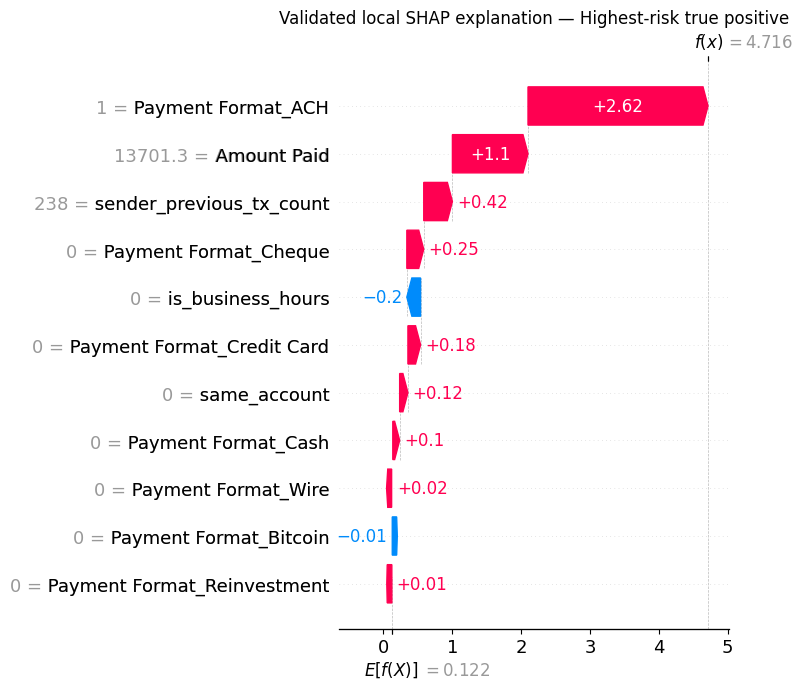


##### Interpretation — Highest-risk true positive

This case is a laundering transaction correctly flagged. The pipeline assigned a risk score of
**0.991125**, above the selected threshold of
**0.892163**.

The strongest positive contributions were `Payment Format_ACH` (+2.615), `Amount Paid` (+1.098), `sender_previous_tx_count` (+0.417). The
strongest negative contributions were `is_business_hours` (-0.200), `Payment Format_Bitcoin` (-0.009). Their combined
effect, together with the model baseline and the remaining features,
produced a validated raw margin of **4.7156**.

This explanation describes why the model produced the alert. It does not
prove that the positively contributing features caused laundering, and
the false-positive case is especially important for identifying patterns
that may create unnecessary analyst workload.


In [ ]:
true_positive_local_result = (
    explain_test_transaction(
        test_position=(
            highest_risk_true_positive
        ),
        case_label=(
            "Highest-risk true positive"
        ),
    )
)


#### 8.16.3 Highest-risk false-positive alert

The second local explanation examines the legitimate transaction with the highest score among the false-positive alerts. This case helps identify legitimate patterns that the classifier may confuse with laundering activity.


Highest-risk false positive
Test position:                 50,209
Original index:                3467282
Actual label:                  0
Predicted label:               1
Pipeline risk score:           0.990650
Classifier risk score:         0.990650
Raw XGBoost margin:            4.662943
Sigmoid(raw margin):           0.990650
Decision threshold:            0.892163
Maximum probability error:     0.0000000258
SHAP reconstruction error:     0.0000006701

Original transaction:


,Payment Format,Amount Paid,sender_previous_tx_count,is_business_hours,same_account
3467282,ACH,12170.019531,3,1,0



Validated feature contributions:


,feature,feature_value,shap_value,effect
0,Payment Format_ACH,1.000000,2.353092,Increases laundering-risk margin
1,Amount Paid,12170.019531,1.263321,Increases laundering-risk margin
2,sender_previous_tx_count,3.000000,0.224402,Increases laundering-risk margin
3,is_business_hours,1.000000,0.215135,Increases laundering-risk margin
4,Payment Format_Credit Card,0.000000,0.183380,Increases laundering-risk margin
5,same_account,0.000000,0.124345,Increases laundering-risk margin
6,Payment Format_Cheque,0.000000,0.091938,Increases laundering-risk margin
7,Payment Format_Cash,0.000000,0.082389,Increases laundering-risk margin
8,Payment Format_Bitcoin,0.000000,-0.022403,Decreases laundering-risk margin
9,Payment Format_Wire,0.000000,0.018604,Increases laundering-risk margin


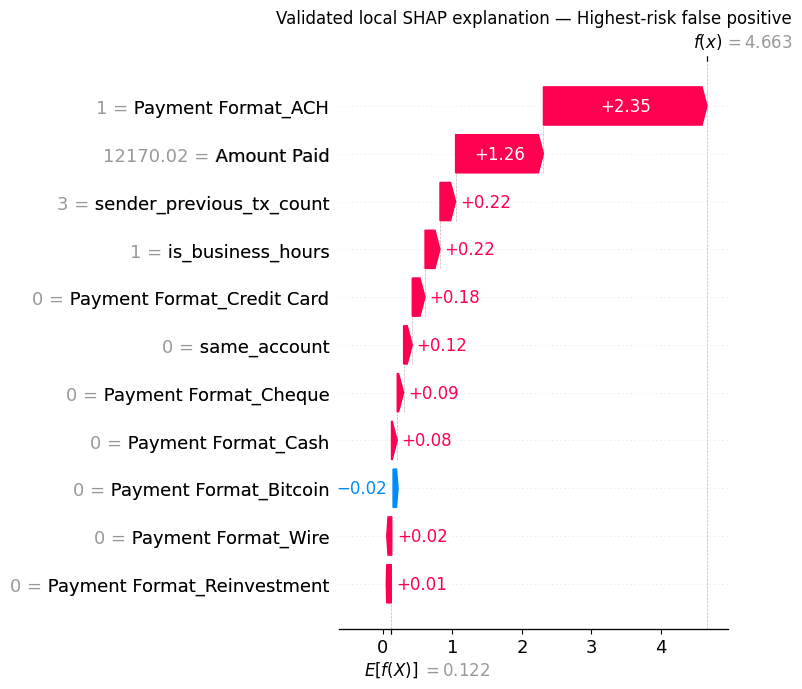


##### Interpretation — Highest-risk false positive

This case is a legitimate transaction incorrectly flagged. The pipeline assigned a risk score of
**0.990650**, above the selected threshold of
**0.892163**.

The strongest positive contributions were `Payment Format_ACH` (+2.353), `Amount Paid` (+1.263), `sender_previous_tx_count` (+0.224). The
strongest negative contributions were `Payment Format_Bitcoin` (-0.022). Their combined
effect, together with the model baseline and the remaining features,
produced a validated raw margin of **4.6629**.

This explanation describes why the model produced the alert. It does not
prove that the positively contributing features caused laundering, and
the false-positive case is especially important for identifying patterns
that may create unnecessary analyst workload.


In [ ]:
false_positive_local_result = (
    explain_test_transaction(
        test_position=(
            highest_risk_false_positive
        ),
        case_label=(
            "Highest-risk false positive"
        ),
    )
)


### 8.17 Explainability conclusion

The SHAP analysis is now technically aligned with the fitted XGBoost pipeline. Global and local explanations use the same sparse transformed representation used during training and scoring, and each explanation is numerically validated against the model's raw margin.

The global analysis identifies the features that most strongly influence the model across the test sample, while the two local cases show how positive and negative contributions combine for an individual alert. The false-positive explanation is particularly relevant because it exposes patterns that may increase operational workload even when the transaction is legitimate.

The explanations remain subject to three limitations:

1. the dataset is synthetic and may contain generator-specific rules;
2. the selected operating threshold was chosen retrospectively on the same held-out set used for comparison;
3. SHAP explains the classifier's learned associations and does not establish causality.

With model evaluation, operating-point analysis, rubric metrics, and validated explainability complete, Section 8 is finished. The notebook can now proceed to the critical conclusion in Section 9.


## 9. Critical Conclusion

This section consolidates the technical, operational and methodological conclusions of AMLGuard.

The objective was not to maximise accuracy on an extremely imbalanced dataset. It was to build a reproducible classification pipeline capable of ranking suspicious transactions, quantifying the investigation workload and documenting the limitations that prevent an academic experiment from being treated as a production AML system.

### 9.1 Project objective and main outcome

AMLGuard was developed with the IBM Transactions for Anti-Money Laundering HI-Small dataset, containing **5,078,345 transactions** and **5,177 labelled laundering cases**. The positive class therefore represents approximately **0.1019%** of the data.

This class distribution made accuracy unsuitable as the main model-selection criterion. A classifier predicting every transaction as legitimate would appear highly accurate while detecting no laundering activity.

The pipeline therefore prioritised:

- Average Precision and precision–recall behaviour;
- recall under equal alert budgets;
- recall under minimum precision requirements;
- the number of alerts required to detect one laundering transaction;
- explainability of global and individual predictions.

Among the evaluated candidates, the **XGBoost model trained with `scale_pos_weight`** provided the strongest overall ranking performance and was selected as the leading model.

### 9.2 Difficulties encountered

Several difficulties materially affected the project design.

**Extreme class imbalance.** Only about one transaction in every 981 is labelled as laundering. Small changes in the number of true positives or false positives can therefore produce large changes in minority-class precision.

**Dataset scale.** More than five million rows increased memory consumption, model-training time and the cost of repeated experiments. Tree-model parameters and SHAP sample sizes had to remain computationally realistic.

**Leakage-safe feature engineering.** Sender history had to be calculated in timestamp order with `cumcount()`, so each transaction used only activity observed before that row. A global account frequency would have incorporated future information.

**Categorical imbalance treatment.** Standard SMOTE was not executed because interpolation after one-hot encoding could create fractional and invalid payment-category combinations. A categorical-aware strategy such as SMOTENC requires a separate experimental design.

**Threshold selection.** The default threshold of 0.50 produced incomparable alert volumes across models. Operational comparison therefore required equal alert budgets and minimum-precision scenarios.

**Explainability consistency.** During SHAP development, converting the sparse transformed matrix to a dense array changed XGBoost predictions because absent sparse entries and explicit numerical zeros were treated differently. The final implementation preserves the sparse representation for scoring and SHAP computation and validates every explanation against the model's raw margin.

### 9.3 Data quality and limitations

The dataset presented strong structural quality for an academic pipeline: no missing values were found, timestamps were parseable and only nine exact duplicate rows were detected. The duplicates were retained because identical transaction records are not sufficient evidence of data corruption in a payment log.

However, structural completeness does not guarantee real-world representativeness.

The principal limitations are:

- the data is synthetic and may contain simulator-specific rules;
- the observed period covers only approximately 18 days;
- the dataset does not include complete KYC, customer profile, sanctions, geography or investigation-history information;
- cross-currency transactions contain no labelled laundering cases, preventing a meaningful test of that hypothesis;
- account and bank identifiers were excluded to reduce memorisation, but this also limits entity-level modelling;
- the random stratified split does not reproduce a true future deployment period;
- transactions from the same entities may appear in both training and test sets;
- the laundering labels reflect the simulator's definition of illicit activity, not confirmed regulatory investigations.

Consequently, the results demonstrate modelling competence and operational reasoning, but they do not estimate the performance that a bank should expect on real production data.

### 9.4 Final model performance in operational terms

The selected demonstration operating point uses the weighted XGBoost with a threshold of approximately **0.8922**.

| Metric | Result | Operational interpretation |
|---|---:|---|
| Average Precision | **0.036833** | Best overall ranking among the evaluated candidates |
| Accuracy | **96.62%** | Secondary metric because legitimate transactions dominate the dataset |
| Precision | **2.00%** | Approximately one laundering case per 50 reviewed alerts |
| Recall | **67.03%** | About two-thirds of the labelled laundering transactions are detected |
| Alerts | **52,044** | **3.42%** of the test transactions are sent for review |
| True positives | **1,041** | Laundering transactions correctly identified |
| False positives | **51,003** | Legitimate transactions requiring unnecessary review |
| False negatives | **512** | Laundering transactions left undetected |
| True negatives | **1,470,948** | Legitimate transactions correctly left without an alert |

The result is useful but not operationally inexpensive. Detecting 1,041 laundering transactions requires reviewing 52,044 alerts. At the same time, 512 labelled laundering transactions remain undetected.

This is a more informative conclusion than reporting accuracy alone: the model improves risk ranking substantially, but the compliance team still faces a large false-positive workload and material residual risk.

### 9.5 False-positive and false-negative trade-off

The selected threshold represents an analytical compromise rather than a universally optimal decision.

Lowering the threshold would detect more laundering transactions, reducing false negatives and regulatory exposure. The cost would be a much larger investigation queue and a lower proportion of useful alerts.

Raising the threshold would improve alert precision and reduce analyst workload. The cost would be more undetected laundering cases.

The appropriate operating point therefore depends on information that is not available in this dataset, including:

- analyst capacity and service-level agreements;
- average investigation time and cost;
- the financial and regulatory cost of a missed case;
- risk appetite by customer, product and jurisdiction;
- escalation policies and the availability of secondary review rules.

The threshold was selected retrospectively on the same held-out set used for comparison. A production workflow must select the threshold on a validation period and report final performance once on a separate future test period.

### 9.6 Explainability, governance and model risk

The SHAP stage provides both global and local explanations for the selected XGBoost model. The implementation preserves the same sparse transformed representation used during training and verifies that the SHAP contributions reconstruct the model's raw margin.

These explanations improve auditability by showing which features move an individual transaction toward or away from a higher risk score. They do not prove causality and should not be used as automatic evidence of criminal behaviour.

Particular caution is required for features that may encode simulator-specific relationships. `same_account`, for example, overlaps conceptually with reinvestment behaviour and may capture rules of the synthetic generator rather than a stable real-world pattern.

A governed deployment would require:

- human review before any adverse action;
- versioned model, feature and threshold documentation;
- validation by compliance and model-risk teams;
- monitoring of alert volume, precision proxies and feature drift;
- periodic back-testing on newly investigated cases;
- explicit controls against using model explanations as causal conclusions.

### 9.7 Future improvement roadmap

| Priority | Improvement | Expected value |
|---|---|---|
| 1 | Temporal and entity-aware validation | Measures generalisation to future periods and unseen accounts instead of relying only on a random split |
| 2 | Independent threshold calibration | Separates model comparison, operating-point selection and final evaluation |
| 3 | Rolling behavioural features | Adds transaction velocity over multiple windows, counterparty diversity and amount deviations |
| 4 | Graph features with NetworkX | Captures fan-in, fan-out, cycles, hubs and laundering chains that tabular features cannot represent |
| 5 | Sensitivity analysis without `same_account` | Quantifies dependence on a potentially synthetic or confounded signal |
| 6 | SMOTENC and additional cost-sensitive methods | Compares categorical-aware resampling without generating invalid one-hot combinations |
| 7 | Probability calibration | Improves the interpretation and stability of risk scores across periods |
| 8 | Ensembles and ranking optimisation | Tests whether complementary models improve performance in the highest-risk region |
| 9 | FastAPI, Docker, MLflow and DVC | Adds reproducible scoring, packaging, experiment tracking and data/model versioning |
| 10 | Streamlit analyst interface and monitoring | Supports human triage, explanation review, workload tracking and drift detection |

The next modelling priority should be validation quality and richer behavioural or network information, not simply adding more algorithms to the current feature set.

### 9.8 Minimal scoring interface

The function below demonstrates how the selected pipeline can score one transaction while preserving the preprocessing and model steps used during training.

It returns the laundering probability, the selected threshold and the resulting alert decision. The function is a technical demonstration and does not constitute a production decision service.

In [ ]:
FINAL_MODEL_FEATURES = [
    "Payment Format",
    "Amount Paid",
    "sender_previous_tx_count",
    "is_business_hours",
    "same_account",
]


def score_aml_transaction(transaction):
    """Score one transaction with the selected AMLGuard pipeline."""

    if isinstance(transaction, pd.Series):
        transaction = transaction.to_dict()
    else:
        transaction = dict(transaction)

    missing_features = [
        feature
        for feature in FINAL_MODEL_FEATURES
        if feature not in transaction
    ]

    if missing_features:
        raise ValueError(
            "Missing required features: "
            + ", ".join(missing_features)
        )

    scoring_row = pd.DataFrame(
        [
            {
                "Payment Format": str(
                    transaction["Payment Format"]
                ),
                "Amount Paid": float(
                    transaction["Amount Paid"]
                ),
                "sender_previous_tx_count": int(
                    transaction[
                        "sender_previous_tx_count"
                    ]
                ),
                "is_business_hours": int(
                    transaction["is_business_hours"]
                ),
                "same_account": int(
                    transaction["same_account"]
                ),
            }
        ]
    )

    for binary_feature in [
        "is_business_hours",
        "same_account",
    ]:
        if scoring_row.at[0, binary_feature] not in (0, 1):
            raise ValueError(
                f"{binary_feature} must be 0 or 1."
            )

    if scoring_row.at[0, "Amount Paid"] < 0:
        raise ValueError(
            "Amount Paid must be non-negative."
        )

    if (
        scoring_row.at[
            0,
            "sender_previous_tx_count",
        ]
        < 0
    ):
        raise ValueError(
            "sender_previous_tx_count must be "
            "non-negative."
        )

    laundering_probability = float(
        xgboost_weighted.predict_proba(
            scoring_row
        )[0, 1]
    )

    alert_decision = int(
        laundering_probability >= final_threshold
    )

    return {
        "laundering_probability": laundering_probability,
        "decision_threshold": float(final_threshold),
        "alert": alert_decision,
        "model": "XGBoost — Scale Pos Weight",
    }


# Reproducible smoke test using the selected true-positive case.
demo_transaction = X_test.iloc[
    highest_risk_true_positive
]

demo_score = score_aml_transaction(
    demo_transaction
)

expected_demo_score = float(
    fresh_final_scores[
        highest_risk_true_positive
    ]
)

if not np.isclose(
    demo_score["laundering_probability"],
    expected_demo_score,
    atol=1e-6,
):
    raise AssertionError(
        "The scoring interface does not reproduce "
        "the stored pipeline score."
    )

print("Minimal scoring interface validated.")
display(
    pd.DataFrame(
        [demo_score]
    )
)

Minimal scoring interface validated.


,laundering_probability,decision_threshold,alert,model
0,0.991125,0.892163,1,XGBoost — Scale Pos Weight


### 9.9 Optional FastAPI endpoint

The following cell creates a minimal `/score` endpoint around the validated scoring function. It does not launch a web server automatically, because starting a persistent server would prevent a clean `Restart and run all` execution in Colab.

The API is an optional portfolio extension. The academic pipeline remains complete even when FastAPI is not installed.

In [ ]:
try:
    from fastapi import FastAPI
    from pydantic import BaseModel, Field

    class AMLTransactionRequest(BaseModel):
        payment_format: str
        amount_paid: float = Field(ge=0)
        sender_previous_tx_count: int = Field(ge=0)
        is_business_hours: int = Field(ge=0, le=1)
        same_account: int = Field(ge=0, le=1)


    app = FastAPI(
        title="AMLGuard Scoring API",
        version="0.1.0",
        description=(
            "Minimal demonstration endpoint for the "
            "selected AMLGuard pipeline."
        ),
    )


    @app.get("/health")
    def health_check():
        return {
            "status": "ok",
            "model": "XGBoost — Scale Pos Weight",
        }


    @app.post("/score")
    def score_endpoint(
        request: AMLTransactionRequest,
    ):
        return score_aml_transaction(
            {
                "Payment Format": (
                    request.payment_format
                ),
                "Amount Paid": request.amount_paid,
                "sender_previous_tx_count": (
                    request.sender_previous_tx_count
                ),
                "is_business_hours": (
                    request.is_business_hours
                ),
                "same_account": (
                    request.same_account
                ),
            }
        )


    print(
        "FastAPI app created successfully. "
        "Available routes: /health and /score"
    )

except ImportError:
    app = None
    print(
        "FastAPI or Pydantic is not installed. "
        "The optional API cell was skipped without "
        "affecting the academic pipeline."
    )

FastAPI app created successfully. Available routes: /health and /score


### 9.10 Final conclusion

AMLGuard demonstrates that extreme class imbalance changes both model evaluation and business decision-making.

The weighted XGBoost ranked suspicious transactions better than the other evaluated candidates, but its usefulness cannot be summarised by accuracy. At the selected demonstration operating point, it detects approximately two-thirds of the labelled laundering cases while requiring about 50 investigations for each true positive.

The project therefore reaches a balanced academic conclusion:

- the model produces meaningful risk prioritisation;
- the alert workload remains substantial;
- undetected laundering risk remains material;
- synthetic data and the short observation window limit external validity;
- explainability improves auditability but does not establish causality;
- production use would require independent temporal validation, governance, monitoring and human review.

The main value of the project is not a claim that money laundering has been solved. It is the construction of a documented, leakage-aware and operationally evaluated pipeline that exposes the trade-offs a real compliance team would need to manage.